# Snapshot-based 2D--3D flow agreement


In [17]:
# ============================================================
# 1. IMPORTS AND PROJECT PATHS
# ============================================================

from pathlib import Path
import sys
import json
import importlib
import warnings
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from scipy.stats import wasserstein_distance

NB_DIR = Path.cwd().resolve()
PROJECT_DIR = NB_DIR.parent.parent
FLOW_DIR = PROJECT_DIR / "z.flow_postprocessing"
FLOW_SCRIPTS_DIR = FLOW_DIR / "scripts"

for path in [PROJECT_DIR, FLOW_SCRIPTS_DIR]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)

import theme.plot_theme as ptheme
import shcherbina_utils as shu

importlib.reload(ptheme)
ptheme.apply_theme()

importlib.reload(shu)
shu.apply_plot_style()

# Theme-aware, A4-readable sizing.  This is applied again inside each
# custom plotting function because shu.apply_plot_style() re-applies the
# shared theme whenever a figure is created.
def apply_comparison_style():
    shu.apply_plot_style()

    font_size = max(getattr(ptheme, "FONT_SIZE", 14), 20)
    title_size = max(getattr(ptheme, "TITLE_SIZE", font_size + 2), 26)
    label_size = max(getattr(ptheme, "LABEL_SIZE", font_size), 24)
    tick_size = max(getattr(ptheme, "TICK_SIZE", font_size - 2), 21)
    legend_size = max(getattr(ptheme, "LEGEND_SIZE", font_size - 1), 20)
    annotation_size = max(getattr(ptheme, "ANNOTATION_SIZE", font_size - 2), 19)
    suptitle_size = max(getattr(ptheme, "SUPTITLE_SIZE", title_size + 2), 30)

    plt.rcParams.update({
        "font.size": font_size,
        "axes.titlesize": title_size,
        "axes.labelsize": label_size,
        "xtick.labelsize": tick_size,
        "ytick.labelsize": tick_size,
        "legend.fontsize": legend_size,
        "figure.titlesize": suptitle_size,
    })

    return {
        "font": font_size,
        "title": title_size,
        "label": label_size,
        "tick": tick_size,
        "legend": legend_size,
        "annotation": annotation_size,
        "suptitle": suptitle_size,
    }


PLOT_SIZES = apply_comparison_style()



def enforce_axis_text_sizes(ax):
    """Re-apply A4-readable text sizes after helper functions modify an axis."""
    ax.title.set_fontsize(PLOT_SIZES["title"])
    ax.xaxis.label.set_fontsize(PLOT_SIZES["label"])
    ax.yaxis.label.set_fontsize(PLOT_SIZES["label"])
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=PLOT_SIZES["tick"],
    )


def enforce_colorbar_text_sizes(colorbar):
    """Apply the same readable scale to colorbar labels and ticks."""
    colorbar.ax.tick_params(labelsize=PLOT_SIZES["tick"])
    colorbar.ax.yaxis.label.set_size(PLOT_SIZES["label"])


# Use the thesis TOC-blue when it is explicitly available in the theme.
# Otherwise, use the theme's semantic default, which is the same dark-blue
# family in the shared plotting utilities.
TOC_BLUE = getattr(
    ptheme,
    "TOC_blue",
    getattr(ptheme, "TOC_BLUE", shu.get_color("default")),
)

print(f"Notebook dir     : {NB_DIR}")
print(f"Project dir      : {PROJECT_DIR}")
print(f"Flow scripts dir : {FLOW_SCRIPTS_DIR}")
print(f"Utilities        : {Path(shu.__file__).resolve()}")


Notebook dir     : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\notebooks
Project dir      : C:\Users\Jelle Gortemaker\Documents\Thesis
Flow scripts dir : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\scripts
Utilities        : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\scripts\shcherbina_utils.py


C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\

In [18]:
# ============================================================
# 2. CASE AND SNAPSHOT SETTINGS
# ============================================================

CASE_3D = "run_aug1_f1"
CASE_2D = f"{CASE_3D}_2D"
RUN_TITLE_INFO = "Case AUG-1-F1 Production"

INPUT_DIR = (NB_DIR / "../data/input").resolve()
RESULTS_ROOT = (NB_DIR / "../results").resolve()

DATA_FILE_3D = INPUT_DIR / f"{CASE_3D}.nc"
DATA_FILE_2D = INPUT_DIR / f"{CASE_2D}.nc"

SNAPSHOT_OBS_SELECTIONS = np.array([0, 3, 7, 13]) * 8

DAY_PER_INDEX_3D = 3.0 / 24.0
DAY_PER_INDEX_2D = 3.0 / 24.0

REFERENCE_START_INDEX_3D = None
REFERENCE_START_INDEX_2D = None
DEFAULT_REFERENCE_START_INDEX = 0

LEVEL_INDICES_3D = (0,)
LEVEL_INDICES_2D = (0,)

DX_3D = None
DY_3D = None
DX_2D = None
DY_2D = None

F0 = 8.0e-5
ACTIVE_RO_THRESHOLD = 0.5
MAX_DISTRIBUTION_SAMPLES = 150_000

NBINS_PDF = 80
NBINS_JPDF = 100
PDF_PERCENTILE_LIMITS = (0.1, 99.9)

SAVE_OUTPUTS = True
SAVE_FIGURES = True

MAKE_SELECTED_CASE_MAPS = True
MAKE_SELECTED_CASE_JPDFS = True
MAKE_SELECTED_CASE_PDF_EVOLUTION = True

CASE_RESULTS_DIR = RESULTS_ROOT / CASE_3D
METRICS_DIR = CASE_RESULTS_DIR / "metrics"
FIG_DIR = CASE_RESULTS_DIR / "figures" / "2D_3D_comparison"
MAP_DIR = FIG_DIR / "map_panels"
JPDF_DIR = FIG_DIR / "jpdf_panels"
PDF_EVOLUTION_DIR = FIG_DIR / "pdf_evolution"

if SAVE_OUTPUTS:
    METRICS_DIR.mkdir(parents=True, exist_ok=True)

if SAVE_FIGURES:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    MAP_DIR.mkdir(parents=True, exist_ok=True)
    JPDF_DIR.mkdir(parents=True, exist_ok=True)
    PDF_EVOLUTION_DIR.mkdir(parents=True, exist_ok=True)

print(f"3D input                : {DATA_FILE_3D}")
print(f"2D input                : {DATA_FILE_2D}")
print(f"RUN_TITLE_INFO          : {RUN_TITLE_INFO}")
print(f"SNAPSHOT_OBS_SELECTIONS : {SNAPSHOT_OBS_SELECTIONS}")
print(f"Case results dir        : {CASE_RESULTS_DIR}")


3D input                : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\data\input\run_aug1_f1.nc
2D input                : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\data\input\run_aug1_f1_2D.nc
RUN_TITLE_INFO          : Case AUG-1-F1 Production
SNAPSHOT_OBS_SELECTIONS : [  0  24  56 104]
Case results dir        : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1_f1


In [19]:
# ============================================================
# 3. HELPERS
# ============================================================

def newest_collection_config(case_name):
    metadata_dir = RESULTS_ROOT / case_name / "metadata"
    candidates = sorted(
        metadata_dir.glob("*_config.json"),
        key=lambda path: path.stat().st_mtime,
    )
    if not candidates:
        return None
    return candidates[-1]


def optional_case_config(case_name):
    config_path = newest_collection_config(case_name)

    if config_path is None:
        return {}

    try:
        with config_path.open("r", encoding="utf-8") as file:
            config = json.load(file)
    except (OSError, json.JSONDecodeError) as error:
        warnings.warn(
            f"Could not read {config_path}: {error}. "
            "The fallback reference index will be used."
        )
        return {}

    config["_config_path"] = str(config_path)
    return config


def resolve_reference_index(config, manual_index):
    if manual_index is not None:
        return int(manual_index)
    return int(config.get("release_time_index", DEFAULT_REFERENCE_START_INDEX))


def elapsed_days(n_times, day_per_index, reference_start_index):
    return (
        np.arange(int(n_times), dtype=float) - int(reference_start_index)
    ) * float(day_per_index)


def snapshot_records_from_obs_indices(time_days, obs_indices):
    time_days = np.asarray(time_days, dtype=float)
    obs_indices = np.asarray(obs_indices, dtype=int)

    if np.any(obs_indices < 0) or np.any(obs_indices >= time_days.size):
        raise IndexError(
            "At least one value in SNAPSHOT_OBS_SELECTIONS is outside the available time range."
        )

    records = []
    for obs_index in obs_indices:
        records.append(
            {
                "obs_index": int(obs_index),
                "actual_day": float(time_days[int(obs_index)]),
            }
        )
    return records


def discover_2d_3d_case_pairs(input_dir):
    input_dir = Path(input_dir)
    cases = []

    for path_3d in sorted(input_dir.glob("run_*.nc")):
        case_3d = path_3d.stem
        if case_3d.endswith("_2D"):
            continue

        path_2d = input_dir / f"{case_3d}_2D.nc"
        if path_2d.exists():
            cases.append(case_3d)

    return cases


def infer_grid_spacing(ds, coordinate_name, fallback=None):
    if coordinate_name in ds.coords:
        coordinate = np.asarray(ds[coordinate_name].values, dtype=float)
        if coordinate.size > 1:
            spacing = float(np.nanmedian(np.abs(np.diff(coordinate))))
            if np.isfinite(spacing) and spacing > 0.0:
                return spacing

    if fallback is not None:
        return float(fallback)

    raise ValueError(f"Could not infer grid spacing from {coordinate_name}.")


def dataset_layout(ds):
    time_dim = shu.find_dim(ds["UVEL"].dims, ["T", "time", "iter"])
    z_dim = shu.find_dim(ds["UVEL"].dims, ["Z", "Zmd", "k", "depth"])
    return time_dim, z_dim


def calculate_kinematics(ds, time_dim, z_dim, time_index, level_indices, dx, dy):
    ro, div_f, strain_f = shu.compute_surface_kinematics(
        ds,
        time_dim=time_dim,
        z_dim=z_dim,
        it=int(time_index),
        levels=list(level_indices),
        dx=float(dx),
        dy=float(dy),
        f0=float(F0),
    )
    return {
        "ro": np.asarray(ro, dtype=float),
        "div_f": np.asarray(div_f, dtype=float),
        "strain_f": np.asarray(strain_f, dtype=float),
    }


def full_domain_active_fraction(ro, threshold=ACTIVE_RO_THRESHOLD):
    ro = np.asarray(ro, dtype=float)
    ny, nx = ro.shape
    full_domain = [{"square_id": 1, "x0": 0, "x1": nx, "y0": 0, "y1": ny}]
    result = shu.compute_pro_per_square(ro, full_domain, threshold)
    return float(result[0]["PRo"])


def deterministic_subsample(values, max_samples):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if max_samples is None or values.size <= int(max_samples):
        return values
    step = int(np.ceil(values.size / int(max_samples)))
    return values[::step]


def distribution_distance(values_2d, values_3d, max_samples=MAX_DISTRIBUTION_SAMPLES):
    values_2d = deterministic_subsample(values_2d, max_samples)
    values_3d = deterministic_subsample(values_3d, max_samples)

    if values_2d.size == 0 or values_3d.size == 0:
        return np.nan, np.nan

    raw = float(wasserstein_distance(values_2d, values_3d))
    q25, q75 = np.nanpercentile(values_3d, [25.0, 75.0])
    iqr_3d = float(q75 - q25)
    normalized = raw / iqr_3d if np.isfinite(iqr_3d) and iqr_3d > 0.0 else np.nan
    return raw, normalized


def divergence_rms_3d(div_f):
    """
    Root-mean-square of the normalized horizontal divergence field.

    Here div_f is the full 2D field of delta/f at one snapshot. The returned
    metric is:
        sqrt( mean( (delta/f)^2 ) )
    over all finite grid cells.

    Interpretation:
    - larger values indicate a stronger domain-wide amplitude of horizontal
      convergence/divergence,
    - smaller values indicate a more weakly divergent, closer-to-nondivergent
      surface flow.

    Because the 2D reduced model cannot explicitly represent the same 3D
    ageostrophic divergence processes, this is used here as a 3D-only context
    metric rather than as a direct 2D--3D agreement measure.
    """
    div_f = np.asarray(div_f, dtype=float)
    finite = np.isfinite(div_f)
    if not np.any(finite):
        return np.nan
    return float(np.sqrt(np.nanmean(div_f[finite] ** 2)))


def common_pdf_edges(arrays, n_bins=NBINS_PDF, percentile_limits=PDF_PERCENTILE_LIMITS, lower_bound=None):
    finite_arrays = []
    for values in arrays:
        values = np.asarray(values, dtype=float)
        values = values[np.isfinite(values)]
        if values.size:
            finite_arrays.append(values)
    if not finite_arrays:
        raise ValueError("No finite values are available for PDF binning.")

    combined = np.concatenate(finite_arrays)
    lower, upper = np.nanpercentile(combined, percentile_limits)
    if lower_bound is not None:
        lower = max(float(lower_bound), float(lower))
    if upper <= lower:
        upper = lower + 1.0
    padding = 0.03 * (upper - lower)
    lower_edge = (lower - padding) if lower_bound is None else max(float(lower_bound), lower - padding)
    upper_edge = upper + padding
    return np.linspace(lower_edge, upper_edge, int(n_bins) + 1)


def common_jpdf_edges(ro_3d, strain_3d, ro_2d, strain_2d, n_bins=NBINS_JPDF):
    ro_all = np.concatenate([
        np.asarray(ro_3d, dtype=float).ravel(),
        np.asarray(ro_2d, dtype=float).ravel(),
    ])
    strain_all = np.concatenate([
        np.asarray(strain_3d, dtype=float).ravel(),
        np.asarray(strain_2d, dtype=float).ravel(),
    ])

    ro_all = ro_all[np.isfinite(ro_all)]
    strain_all = strain_all[np.isfinite(strain_all)]

    # Use the complete finite data range so no valid grid-cell values
    # are excluded from the JPDF.
    xlow, xhigh = np.nanmin(ro_all), np.nanmax(ro_all)
    ylow, yhigh = np.nanmin(strain_all), np.nanmax(strain_all)

    xspan = max(xhigh - xlow, np.finfo(float).eps)
    yspan = max(yhigh - ylow, np.finfo(float).eps)

    xpad = 0.02 * xspan
    ypad = 0.02 * yspan

    x_edges = np.linspace(xlow - xpad, xhigh + xpad, n_bins + 1)
    y_edges = np.linspace(max(0.0, ylow - ypad), yhigh + ypad, n_bins + 1)
    return x_edges, y_edges


def regime_fractions(ro, strain):
    ro = np.asarray(ro, dtype=float)
    strain = np.asarray(strain, dtype=float)
    mask = np.isfinite(ro) & np.isfinite(strain)
    if not np.any(mask):
        return {"AVD": np.nan, "SD": np.nan, "CVD": np.nan}
    ro = ro[mask]
    strain = strain[mask]
    avd = (ro < 0.0) & (np.abs(ro) > strain)
    cvd = (ro > 0.0) & (np.abs(ro) > strain)
    sd = ~(avd | cvd)
    total = float(ro.size)
    return {"AVD": np.sum(avd) / total, "SD": np.sum(sd) / total, "CVD": np.sum(cvd) / total}


def safe_filename_day(day):
    return f"{float(day):g}".replace("-", "m").replace(".", "p")


def lighten_color(color, amount):
    """Mix color with white. amount=0 returns original; amount=1 returns white."""
    rgb = np.array(to_rgb(color))
    return tuple((1 - amount) * rgb + amount * np.ones(3))


def progressive_shades(base_color, n):
    """Return clearly separated dark-to-light shades of one theme color."""
    if n == 1:
        return [base_color]

    # A wider lightness range makes consecutive snapshots distinguishable
    # when printed on A4, while the final curve remains visible.
    mix_values = np.linspace(0.0, 0.72, n)
    return [lighten_color(base_color, float(v)) for v in mix_values]


In [20]:
# ============================================================
# 4. COMBINED PANEL PLOTTING HELPERS
# ============================================================

def plot_side_by_side_field_panel(
    field_3d,
    field_2d,
    dx,
    dy,
    title_left,
    title_right,
    suptitle,
    cbar_label,
    cmap,
    vmin,
    vmax,
    output_path=None,
):
    apply_comparison_style()

    if isinstance(cmap, str):
        cmap = shu.get_cmap(cmap)

    field_3d = np.asarray(field_3d, dtype=float)
    field_2d = np.asarray(field_2d, dtype=float)

    ny = min(field_3d.shape[0], field_2d.shape[0])
    nx = min(field_3d.shape[1], field_2d.shape[1])
    field_3d = field_3d[:ny, :nx]
    field_2d = field_2d[:ny, :nx]

    x_edges = np.arange(nx + 1) * dx / 1000.0
    y_edges = np.arange(ny + 1) * dy / 1000.0

    fig = plt.figure(figsize=(14.2, 7.0), facecolor="white")
    ax_left = fig.add_axes([0.050, 0.110, 0.385, 0.770])
    ax_right = fig.add_axes([0.452, 0.110, 0.385, 0.770])
    cax = fig.add_axes([0.860, 0.110, 0.024, 0.770])

    pcm = None

    for index, (ax, field, title) in enumerate(
        zip(
            [ax_left, ax_right],
            [field_3d, field_2d],
            [title_left, title_right],
        )
    ):
        ax.set_facecolor("white")
        pcm = ax.pcolormesh(
            x_edges,
            y_edges,
            field,
            shading="flat",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )

        shu.format_axis(
            ax,
            title=title,
            xlabel="x [km]",
            ylabel="y [km]" if index == 0 else None,
            grid=True,
            equal=True,
        )
        enforce_axis_text_sizes(ax)

    ax_right.tick_params(axis="y", labelleft=False)

    colorbar = fig.colorbar(pcm, cax=cax)
    colorbar.set_label(cbar_label)
    enforce_colorbar_text_sizes(colorbar)

    fig.suptitle(
        suptitle,
        fontsize=PLOT_SIZES["suptitle"],
        y=0.99,
    )

    if output_path is not None:
        fig.savefig(
            output_path,
            dpi=getattr(ptheme, "SAVE_DPI", 300),
            bbox_inches="tight",
            facecolor="white",
            transparent=False,
        )

    plt.show()


def make_log_jpdf(ro, strain, x_edges, y_edges):
    ro = np.asarray(ro, dtype=float).ravel()
    strain = np.asarray(strain, dtype=float).ravel()

    mask = np.isfinite(ro) & np.isfinite(strain)
    ro = ro[mask]
    strain = strain[mask]

    histogram, _, _ = np.histogram2d(
        ro,
        strain,
        bins=[x_edges, y_edges],
        density=True,
    )

    if np.nanmax(histogram) > 0.0:
        normalized = histogram / np.nanmax(histogram)
    else:
        normalized = histogram.copy()

    with np.errstate(divide="ignore"):
        log_histogram = np.log10(normalized)

    log_histogram[~np.isfinite(log_histogram)] = np.nan
    return histogram, log_histogram


def _enlarge_regime_characteristics(ax):
    regime_label_size = max(PLOT_SIZES["title"] + 4, 30)

    for text_artist in ax.texts:
        if text_artist.get_text() in {"AVD", "SD", "CVD"}:
            text_artist.set_fontsize(regime_label_size)
            text_artist.set_fontweight("bold")
            text_artist.set_alpha(0.92)


def _add_regime_fraction_legend(ax, fractions):
    invisible_handle = Line2D(
        [],
        [],
        linestyle="none",
        marker="",
        color="none",
    )

    label = (
        rf"AVD = {fractions['AVD']:.2f}"
        "\n"
        rf"SD = {fractions['SD']:.2f}"
        "\n"
        rf"CVD = {fractions['CVD']:.2f}"
    )

    legend = ax.legend(
        [invisible_handle],
        [label],
        loc="upper left",
        bbox_to_anchor=(0.012, 0.988),
        borderaxespad=0.0,
        handlelength=0.0,
        handletextpad=0.0,
        frameon=True,
        framealpha=0.92,
        fontsize=PLOT_SIZES["legend"],
        title_fontsize=PLOT_SIZES["legend"] + 2,
    )

    legend.get_frame().set_facecolor("white")
    legend.get_frame().set_edgecolor("0.72")


def plot_combined_jpdf_panel(
    ro_3d,
    strain_3d,
    ro_2d,
    strain_2d,
    title,
    output_path=None,
):
    apply_comparison_style()

    x_edges, y_edges = common_jpdf_edges(
        ro_3d,
        strain_3d,
        ro_2d,
        strain_2d,
        n_bins=NBINS_JPDF,
    )

    _, log_histogram_3d = make_log_jpdf(
        ro_3d,
        strain_3d,
        x_edges,
        y_edges,
    )
    _, log_histogram_2d = make_log_jpdf(
        ro_2d,
        strain_2d,
        x_edges,
        y_edges,
    )

    fig = plt.figure(figsize=(15.4, 7.4), facecolor="white")

    ax_left = fig.add_axes([0.052, 0.125, 0.410, 0.725])
    ax_right = fig.add_axes([0.464, 0.125, 0.410, 0.725])
    cax = fig.add_axes([0.895, 0.125, 0.024, 0.725])

    cmap = shu.get_cmap("jpdf")
    vmin, vmax = -2.0, 0.0

    fractions_3d = regime_fractions(ro_3d, strain_3d)
    fractions_2d = regime_fractions(ro_2d, strain_2d)

    pcm = None

    for index, (ax, log_histogram, panel_title, fractions) in enumerate(
        zip(
            [ax_left, ax_right],
            [log_histogram_3d, log_histogram_2d],
            ["3D", "2D"],
            [fractions_3d, fractions_2d],
        )
    ):
        ax.set_facecolor("white")

        pcm = ax.pcolormesh(
            x_edges,
            y_edges,
            log_histogram.T,
            shading="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )

        x_line = np.linspace(x_edges[0], x_edges[-1], 500)
        ax.plot(
            x_line,
            np.abs(x_line),
            "--",
            color=shu.get_color("reference"),
            lw=1.8,
            alpha=0.85,
        )

        shu.add_regime_labels(ax, x_edges, y_edges)
        _enlarge_regime_characteristics(ax)

        shu.format_axis(
            ax,
            title=panel_title,
            xlabel=r"$\zeta/f_0$",
            ylabel=r"$\sigma/|f_0|$" if index == 0 else None,
            grid=True,
        )
        enforce_axis_text_sizes(ax)
        _add_regime_fraction_legend(ax, fractions)

    ax_right.tick_params(axis="y", labelleft=False)

    colorbar = fig.colorbar(pcm, cax=cax)
    colorbar.set_label(r"$\log_{10}(P/P_{\max})$")
    enforce_colorbar_text_sizes(colorbar)

    fig.suptitle(
        title,
        fontsize=PLOT_SIZES["suptitle"],
        y=0.975,
    )

    if output_path is not None:
        fig.savefig(
            output_path,
            dpi=getattr(ptheme, "SAVE_DPI", 300),
            bbox_inches="tight",
            facecolor="white",
            transparent=False,
        )

    plt.show()


def plot_pdf_evolution_panel(
    selected_snapshot_data,
    selected_metrics_df,
    title,
    output_path=None,
):
    apply_comparison_style()

    ordered = (
        selected_metrics_df
        .sort_values("actual_day_3d")
        .reset_index(drop=True)
    )

    ordered_days = ordered["actual_day_3d"].astype(float).to_list()
    number_of_times = len(ordered_days)

    sequential_cmap = plt.get_cmap("plasma")
    sample_positions = np.linspace(0.06, 0.78, number_of_times)
    snapshot_colors = [
        sequential_cmap(position)
        for position in sample_positions
    ]

    ro_arrays = []
    strain_arrays = []

    for day in ordered_days:
        snapshot = selected_snapshot_data[day]
        ro_arrays.extend([snapshot["ro_3d"], snapshot["ro_2d"]])
        strain_arrays.extend(
            [snapshot["strain_3d"], snapshot["strain_2d"]]
        )

    ro_edges = common_pdf_edges(
        ro_arrays,
        n_bins=NBINS_PDF,
        percentile_limits=PDF_PERCENTILE_LIMITS,
    )
    strain_edges = common_pdf_edges(
        strain_arrays,
        n_bins=NBINS_PDF,
        percentile_limits=PDF_PERCENTILE_LIMITS,
        lower_bound=0.0,
    )

    ro_centers = 0.5 * (ro_edges[:-1] + ro_edges[1:])
    strain_centers = 0.5 * (
        strain_edges[:-1] + strain_edges[1:]
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(17.0, 10.4),
        constrained_layout=True,
        facecolor="white",
        sharex="row",
        sharey="row",
    )

    ax_ro_3d = axes[0, 0]
    ax_ro_2d = axes[0, 1]
    ax_strain_3d = axes[1, 0]
    ax_strain_2d = axes[1, 1]

    for index, row in ordered.iterrows():
        day = float(row["actual_day_3d"])
        snapshot = selected_snapshot_data[day]
        line_color = snapshot_colors[index]

        ro_3d_values = np.ravel(snapshot["ro_3d"])
        ro_2d_values = np.ravel(snapshot["ro_2d"])
        strain_3d_values = np.ravel(snapshot["strain_3d"])
        strain_2d_values = np.ravel(snapshot["strain_2d"])

        ro_3d_values = ro_3d_values[np.isfinite(ro_3d_values)]
        ro_2d_values = ro_2d_values[np.isfinite(ro_2d_values)]
        strain_3d_values = strain_3d_values[
            np.isfinite(strain_3d_values)
        ]
        strain_2d_values = strain_2d_values[
            np.isfinite(strain_2d_values)
        ]

        histogram_ro_3d, _ = np.histogram(
            ro_3d_values,
            bins=ro_edges,
            density=True,
        )
        histogram_ro_2d, _ = np.histogram(
            ro_2d_values,
            bins=ro_edges,
            density=True,
        )
        histogram_strain_3d, _ = np.histogram(
            strain_3d_values,
            bins=strain_edges,
            density=True,
        )
        histogram_strain_2d, _ = np.histogram(
            strain_2d_values,
            bins=strain_edges,
            density=True,
        )

        histogram_ro_3d = shu.normalize_hist(histogram_ro_3d)
        histogram_ro_2d = shu.normalize_hist(histogram_ro_2d)
        histogram_strain_3d = shu.normalize_hist(
            histogram_strain_3d
        )
        histogram_strain_2d = shu.normalize_hist(
            histogram_strain_2d
        )

        line_kwargs = {
            "color": line_color,
            "lw": 3.5,
            "alpha": 0.98,
        }

        ax_ro_3d.plot(ro_centers, histogram_ro_3d, **line_kwargs)
        ax_ro_2d.plot(ro_centers, histogram_ro_2d, **line_kwargs)
        ax_strain_3d.plot(
            strain_centers,
            histogram_strain_3d,
            **line_kwargs,
        )
        ax_strain_2d.plot(
            strain_centers,
            histogram_strain_2d,
            **line_kwargs,
        )

    ax_ro_3d.set_title("3D Vorticity")
    ax_ro_2d.set_title("2D Vorticity")
    ax_strain_3d.set_title("3D Strain rate")
    ax_strain_2d.set_title("2D Strain rate")

    for axis in (ax_ro_3d, ax_ro_2d):
        axis.set_xlabel(r"$\zeta/f$")
        axis.set_ylabel("PDF")
        axis.grid(True, alpha=0.35)
        axis.set_ylim(bottom=0.0)
        enforce_axis_text_sizes(axis)

    for axis in (ax_strain_3d, ax_strain_2d):
        axis.set_xlabel(r"$\alpha/f$")
        axis.set_ylabel("PDF")
        axis.grid(True, alpha=0.35)
        axis.set_ylim(bottom=0.0)
        enforce_axis_text_sizes(axis)

    ax_ro_2d.tick_params(axis="y", labelleft=False)
    ax_strain_2d.tick_params(axis="y", labelleft=False)
    ax_ro_2d.set_ylabel(None)
    ax_strain_2d.set_ylabel(None)

    vorticity_handles = []
    strain_handles = []

    for index, row in ordered.iterrows():
        day = float(row["actual_day_3d"])
        line_color = snapshot_colors[index]

        vorticity_handles.append(
            Line2D(
                [0],
                [0],
                color=line_color,
                lw=3.6,
                label=(
                    rf"T={day:g} d; "
                    rf"$W_1^*="
                    rf"{row['vorticity_wasserstein_iqr_normalized']:.3f}$"
                ),
            )
        )

        strain_handles.append(
            Line2D(
                [0],
                [0],
                color=line_color,
                lw=3.6,
                label=(
                    rf"T={day:g} d; "
                    rf"$W_1^*="
                    rf"{row['strain_wasserstein_iqr_normalized']:.3f}$"
                ),
            )
        )

    ax_ro_3d.legend(
        handles=vorticity_handles,
        loc="upper right",
        bbox_to_anchor=(0.985, 0.985),
        borderaxespad=0.0,
        title=r"2D-3D $W_1^*$",
        frameon=True,
        framealpha=0.94,
    )

    ax_strain_3d.legend(
        handles=strain_handles,
        loc="upper right",
        bbox_to_anchor=(0.985, 0.985),
        borderaxespad=0.0,
        title=r"2D-3D $W_1^*$",
        frameon=True,
        framealpha=0.94,
    )

    fig.suptitle(
        title,
        fontsize=PLOT_SIZES["suptitle"],
    )

    if output_path is not None:
        fig.savefig(
            output_path,
            dpi=getattr(ptheme, "SAVE_DPI", 300),
            bbox_inches="tight",
            facecolor="white",
            transparent=False,
        )

    plt.show()


In [21]:
# ============================================================
# 5. LOAD THE SELECTED CASE AND COMPUTE SNAPSHOT METRICS
# ============================================================

if not DATA_FILE_3D.exists():
    raise FileNotFoundError(DATA_FILE_3D)

if not DATA_FILE_2D.exists():
    raise FileNotFoundError(DATA_FILE_2D)

config_3d = optional_case_config(CASE_3D)
config_2d = optional_case_config(CASE_2D)

reference_index_3d = resolve_reference_index(config_3d, REFERENCE_START_INDEX_3D)
reference_index_2d = resolve_reference_index(config_2d, REFERENCE_START_INDEX_2D)

print("Reference indices")
print(f"  3D: {reference_index_3d}")
print(f"  2D: {reference_index_2d}")

selected_records = []
selected_snapshot_data = {}

with xr.open_dataset(
    DATA_FILE_3D,
    decode_times=False,
    cache=False,
) as ds_3d, xr.open_dataset(
    DATA_FILE_2D,
    decode_times=False,
    cache=False,
) as ds_2d:

    time_dim_3d, z_dim_3d = dataset_layout(ds_3d)
    time_dim_2d, z_dim_2d = dataset_layout(ds_2d)

    dx_3d = infer_grid_spacing(ds_3d, "X", fallback=DX_3D)
    dy_3d = infer_grid_spacing(ds_3d, "Y", fallback=DY_3D)
    dx_2d = infer_grid_spacing(ds_2d, "X", fallback=DX_2D)
    dy_2d = infer_grid_spacing(ds_2d, "Y", fallback=DY_2D)

    time_days_3d = elapsed_days(
        ds_3d.sizes[time_dim_3d],
        DAY_PER_INDEX_3D,
        reference_index_3d,
    )
    time_days_2d = elapsed_days(
        ds_2d.sizes[time_dim_2d],
        DAY_PER_INDEX_2D,
        reference_index_2d,
    )

    selections_3d = snapshot_records_from_obs_indices(
        time_days_3d,
        SNAPSHOT_OBS_SELECTIONS,
    )
    selections_2d = snapshot_records_from_obs_indices(
        time_days_2d,
        SNAPSHOT_OBS_SELECTIONS,
    )

    for selection_3d, selection_2d in zip(selections_3d, selections_2d):
        obs_index = int(selection_3d["obs_index"])
        actual_day_3d = float(selection_3d["actual_day"])
        actual_day_2d = float(selection_2d["actual_day"])

        diagnostics_3d = calculate_kinematics(
            ds_3d,
            time_dim_3d,
            z_dim_3d,
            obs_index,
            LEVEL_INDICES_3D,
            dx_3d,
            dy_3d,
        )
        diagnostics_2d = calculate_kinematics(
            ds_2d,
            time_dim_2d,
            z_dim_2d,
            obs_index,
            LEVEL_INDICES_2D,
            dx_2d,
            dy_2d,
        )

        active_fraction_3d = full_domain_active_fraction(diagnostics_3d["ro"])
        active_fraction_2d = full_domain_active_fraction(diagnostics_2d["ro"])

        vorticity_w1, vorticity_w1_normalized = distribution_distance(
            diagnostics_2d["ro"],
            diagnostics_3d["ro"],
        )
        strain_w1, strain_w1_normalized = distribution_distance(
            diagnostics_2d["strain_f"],
            diagnostics_3d["strain_f"],
        )
        divergence_proxy = divergence_rms_3d(diagnostics_3d["div_f"])

        selected_records.append(
            {
                "case_3d": CASE_3D,
                "case_2d": CASE_2D,
                "run_title_info": RUN_TITLE_INFO,
                "obs_index": obs_index,
                "actual_day_3d": actual_day_3d,
                "actual_day_2d": actual_day_2d,
                "active_fraction_3d": active_fraction_3d,
                "active_fraction_2d": active_fraction_2d,
                "active_fraction_error_signed": active_fraction_2d - active_fraction_3d,
                "active_fraction_error_absolute": abs(active_fraction_2d - active_fraction_3d),
                "vorticity_wasserstein": vorticity_w1,
                "vorticity_wasserstein_iqr_normalized": vorticity_w1_normalized,
                "strain_wasserstein": strain_w1,
                "strain_wasserstein_iqr_normalized": strain_w1_normalized,
                "divergence_rms_3d": divergence_proxy,
            }
        )

        selected_snapshot_data[actual_day_3d] = {
            "obs_index": obs_index,
            "ro_3d": diagnostics_3d["ro"],
            "ro_2d": diagnostics_2d["ro"],
            "strain_3d": diagnostics_3d["strain_f"],
            "strain_2d": diagnostics_2d["strain_f"],
            "div_3d": diagnostics_3d["div_f"],
            "dx_plot": min(dx_3d, dx_2d),
            "dy_plot": min(dy_3d, dy_2d),
        }

selected_metrics_df = (
    pd.DataFrame(selected_records)
    .sort_values("obs_index")
    .reset_index(drop=True)
)

display(selected_metrics_df)

SELECTED_ACTIVITY_FILE = METRICS_DIR / "submesoscale_activity_selected_snapshots.nc"

if SAVE_OUTPUTS:
    active_fraction_ratio = np.where(
        selected_metrics_df["active_fraction_3d"].to_numpy() > 0.0,
        selected_metrics_df["active_fraction_2d"].to_numpy()
        / selected_metrics_df["active_fraction_3d"].to_numpy(),
        np.nan,
    )

    selected_activity_ds = xr.Dataset(
        data_vars={
            "active_fraction_3d": (
                "snapshot",
                selected_metrics_df["active_fraction_3d"].to_numpy(dtype=float),
            ),
            "active_fraction_2d": (
                "snapshot",
                selected_metrics_df["active_fraction_2d"].to_numpy(dtype=float),
            ),
            "active_fraction_error_signed": (
                "snapshot",
                selected_metrics_df["active_fraction_error_signed"].to_numpy(dtype=float),
            ),
            "active_fraction_error_absolute": (
                "snapshot",
                selected_metrics_df["active_fraction_error_absolute"].to_numpy(dtype=float),
            ),
            "active_fraction_ratio_2d_to_3d": (
                "snapshot",
                active_fraction_ratio,
            ),
        },
        coords={
            "snapshot": np.arange(len(selected_metrics_df), dtype=int),
            "obs_index": (
                "snapshot",
                selected_metrics_df["obs_index"].to_numpy(dtype=int),
            ),
            "time_days_3d": (
                "snapshot",
                selected_metrics_df["actual_day_3d"].to_numpy(dtype=float),
            ),
            "time_days_2d": (
                "snapshot",
                selected_metrics_df["actual_day_2d"].to_numpy(dtype=float),
            ),
        },
        attrs={
            "case_3d": CASE_3D,
            "case_2d": CASE_2D,
            "run_title_info": RUN_TITLE_INFO,
            "active_ro_threshold": float(ACTIVE_RO_THRESHOLD),
            "description": (
                "Selected-snapshot 3D and 2D submesoscale-active area fractions "
                "for later cross-case agreement analysis."
            ),
        },
    )

    selected_activity_ds.to_netcdf(SELECTED_ACTIVITY_FILE)
    print(f"Saved: {SELECTED_ACTIVITY_FILE}")


Reference indices
  3D: 0
  2D: 0


,case_3d,case_2d,run_title_info,obs_index,actual_day_3d,actual_day_2d,active_fraction_3d,active_fraction_2d,active_fraction_error_signed,active_fraction_error_absolute,vorticity_wasserstein,vorticity_wasserstein_iqr_normalized,strain_wasserstein,strain_wasserstein_iqr_normalized,divergence_rms_3d
0,run_aug1_f1,run_aug1_f1_2D,Case AUG-1-F1 Production,0,0.0,0.0,0.013107,0.014370,0.001263,0.001263,0.003404,0.021364,0.003747,0.036277,0.043828
1,run_aug1_f1,run_aug1_f1_2D,Case AUG-1-F1 Production,24,3.0,3.0,0.017590,0.012806,-0.004784,0.004784,0.015475,0.089501,0.015570,0.139787,0.048938
2,run_aug1_f1,run_aug1_f1_2D,Case AUG-1-F1 Production,56,7.0,7.0,0.018341,0.008068,-0.010273,0.010273,0.028231,0.154779,0.026865,0.217940,0.045456
3,run_aug1_f1,run_aug1_f1_2D,Case AUG-1-F1 Production,104,13.0,13.0,0.013412,0.005348,-0.008064,0.008064,0.036214,0.198461,0.034419,0.277652,0.046955


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1_f1\metrics\submesoscale_activity_selected_snapshots.nc


C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


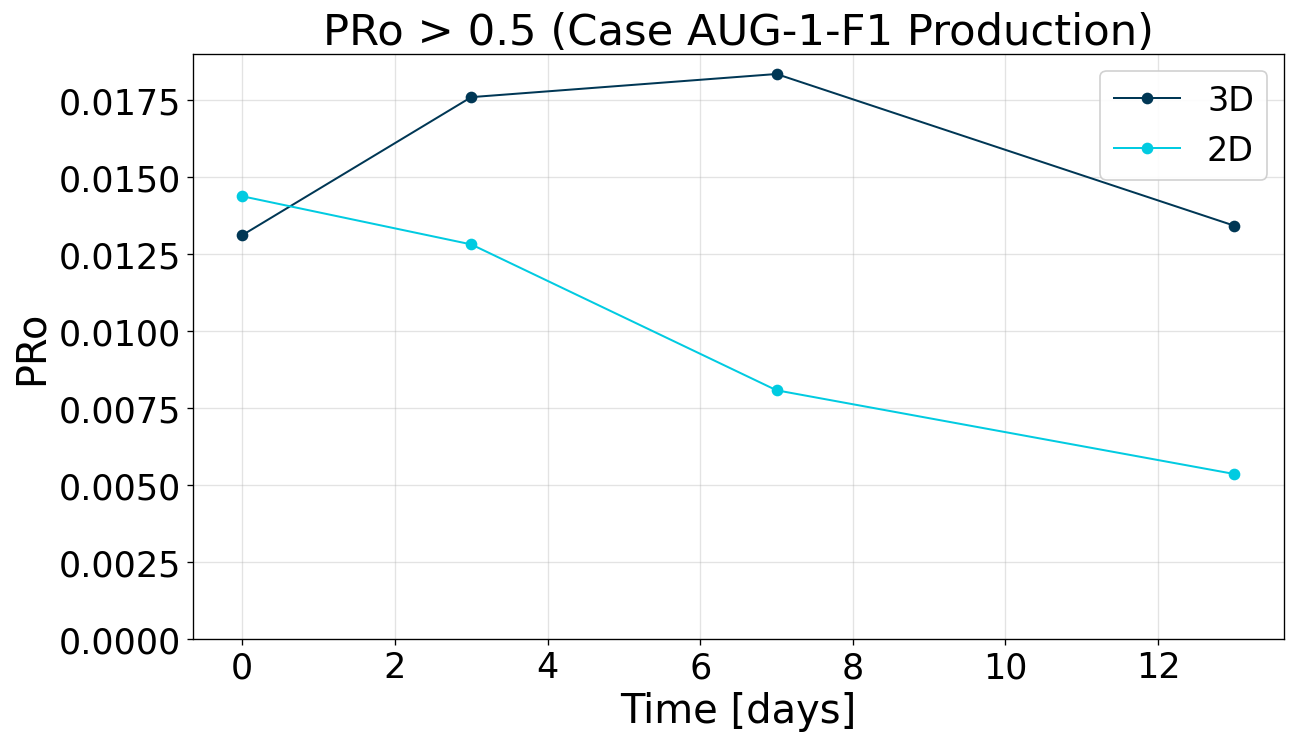

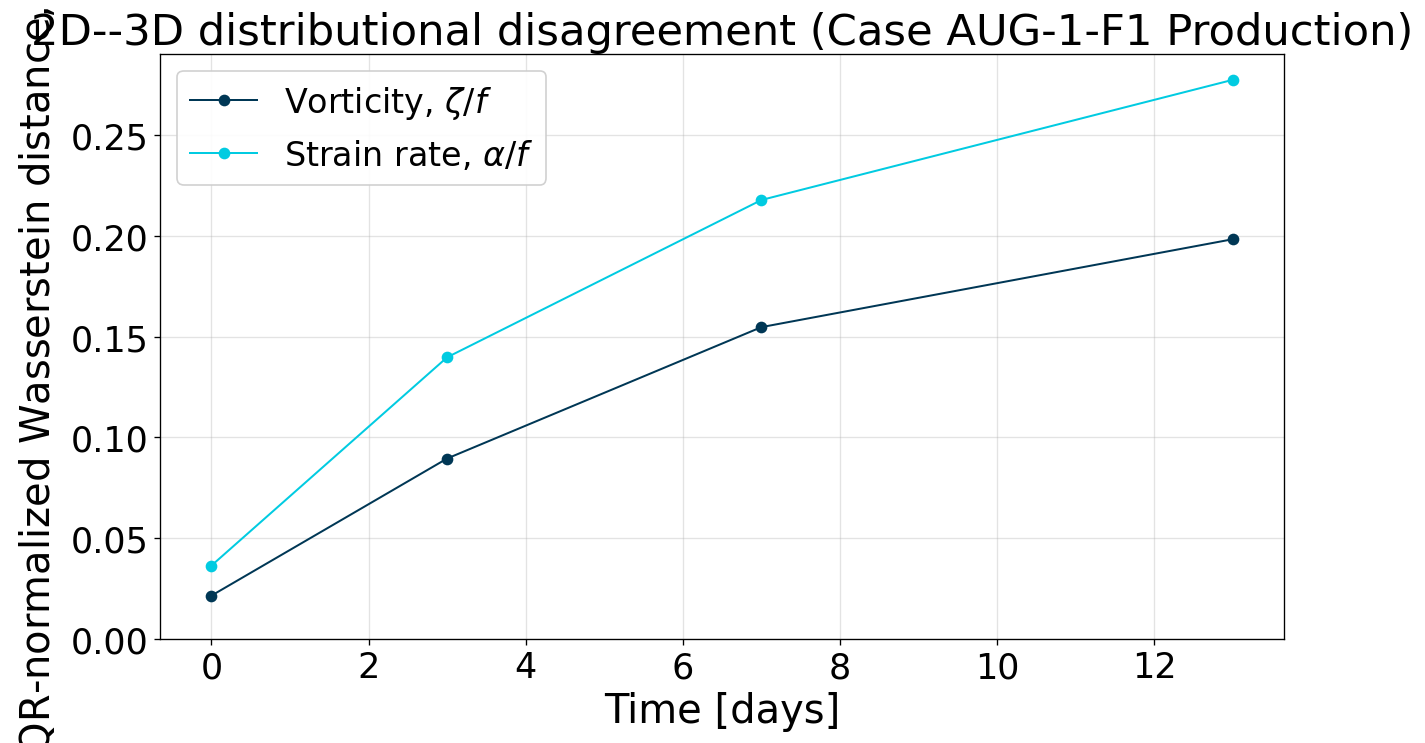

In [22]:
# ============================================================
# 6. METRIC OVERVIEW FIGURES
# ============================================================

apply_comparison_style()

# Shown for inspection only; the values are stored in the selected-snapshot
# NetCDF file and the figure is deliberately not saved.
fig, ax = plt.subplots(figsize=(11.2, 6.6))
ax.plot(
    selected_metrics_df["actual_day_3d"],
    selected_metrics_df["active_fraction_3d"],
    marker="o",
    label="3D",
)
ax.plot(
    selected_metrics_df["actual_day_3d"],
    selected_metrics_df["active_fraction_2d"],
    marker="o",
    label="2D",
)
ax.set_xlabel("Time [days]")
ax.set_ylabel("PRo")
ax.set_ylim(bottom=0.0)
ax.set_title(
    f"PRo > {shu.format_threshold(ACTIVE_RO_THRESHOLD)} "
    f"({RUN_TITLE_INFO})"
)
ax.legend()
enforce_axis_text_sizes(ax)
fig.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(11.2, 6.6))
ax.plot(
    selected_metrics_df["actual_day_3d"],
    selected_metrics_df["vorticity_wasserstein_iqr_normalized"],
    marker="o",
    label=r"Vorticity, $\zeta/f$",
)
ax.plot(
    selected_metrics_df["actual_day_3d"],
    selected_metrics_df["strain_wasserstein_iqr_normalized"],
    marker="o",
    label=r"Strain rate, $\alpha/f$",
)
ax.set_xlabel("Time [days]")
ax.set_ylabel(r"IQR-normalized Wasserstein distance, $W_1^*$")
ax.set_ylim(bottom=0.0)
ax.set_title(f"2D--3D distributional disagreement ({RUN_TITLE_INFO})")
ax.legend()
enforce_axis_text_sizes(ax)
fig.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        FIG_DIR / "selected_case_distribution_distances_snapshots.png",
        dpi=getattr(ptheme, "SAVE_DPI", 300),
        bbox_inches="tight",
        facecolor="white",
        transparent=False,
    )

plt.show()


C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\

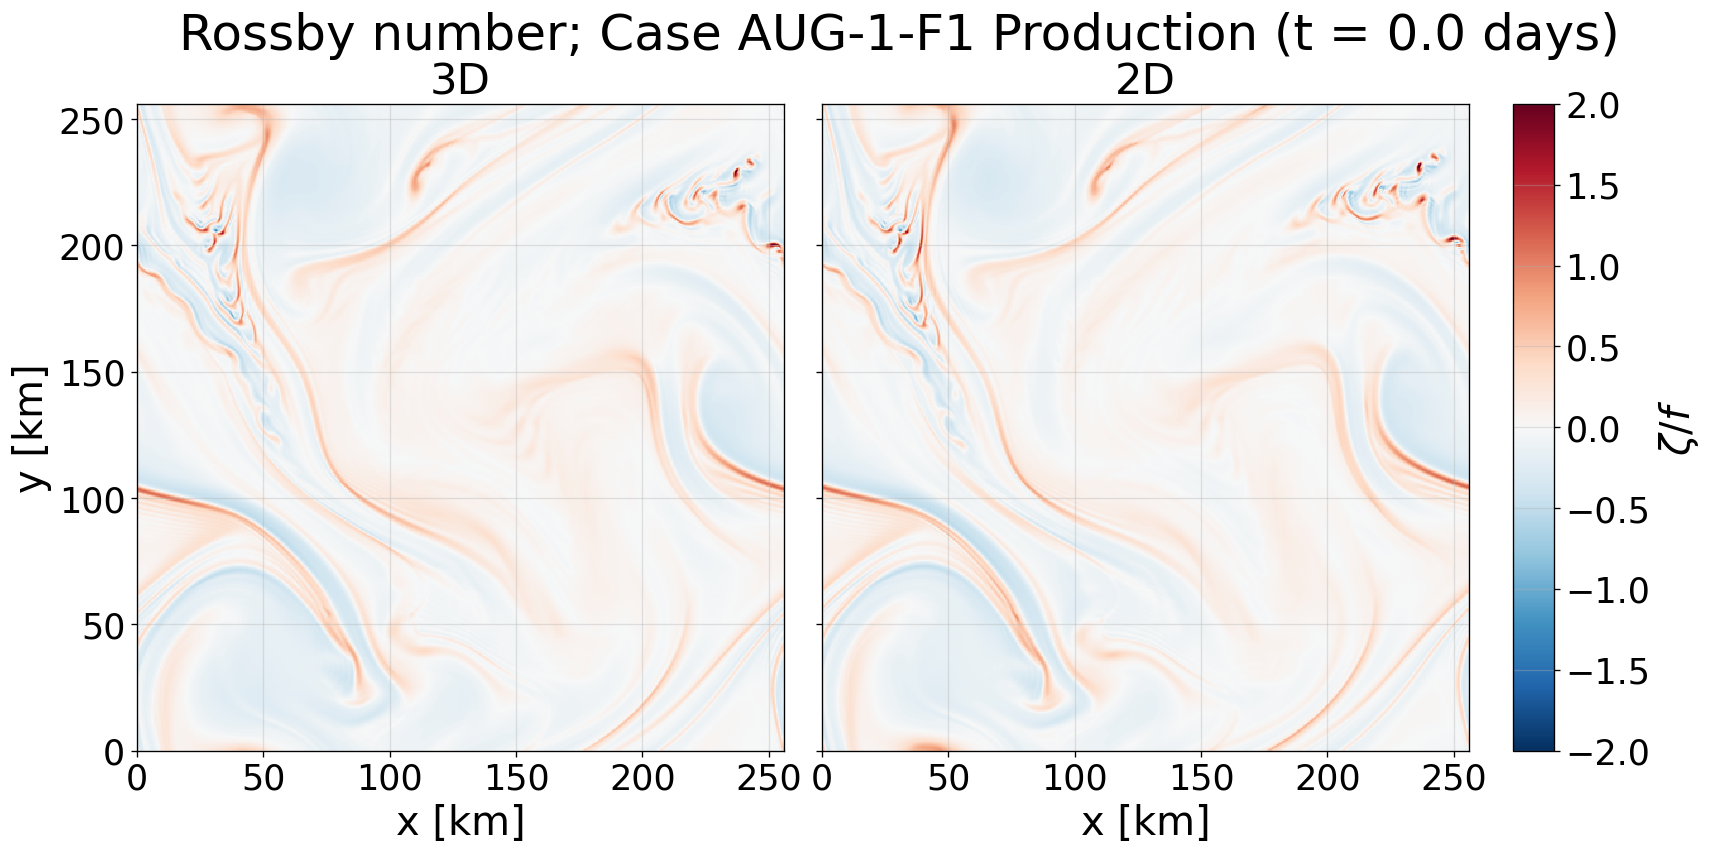

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


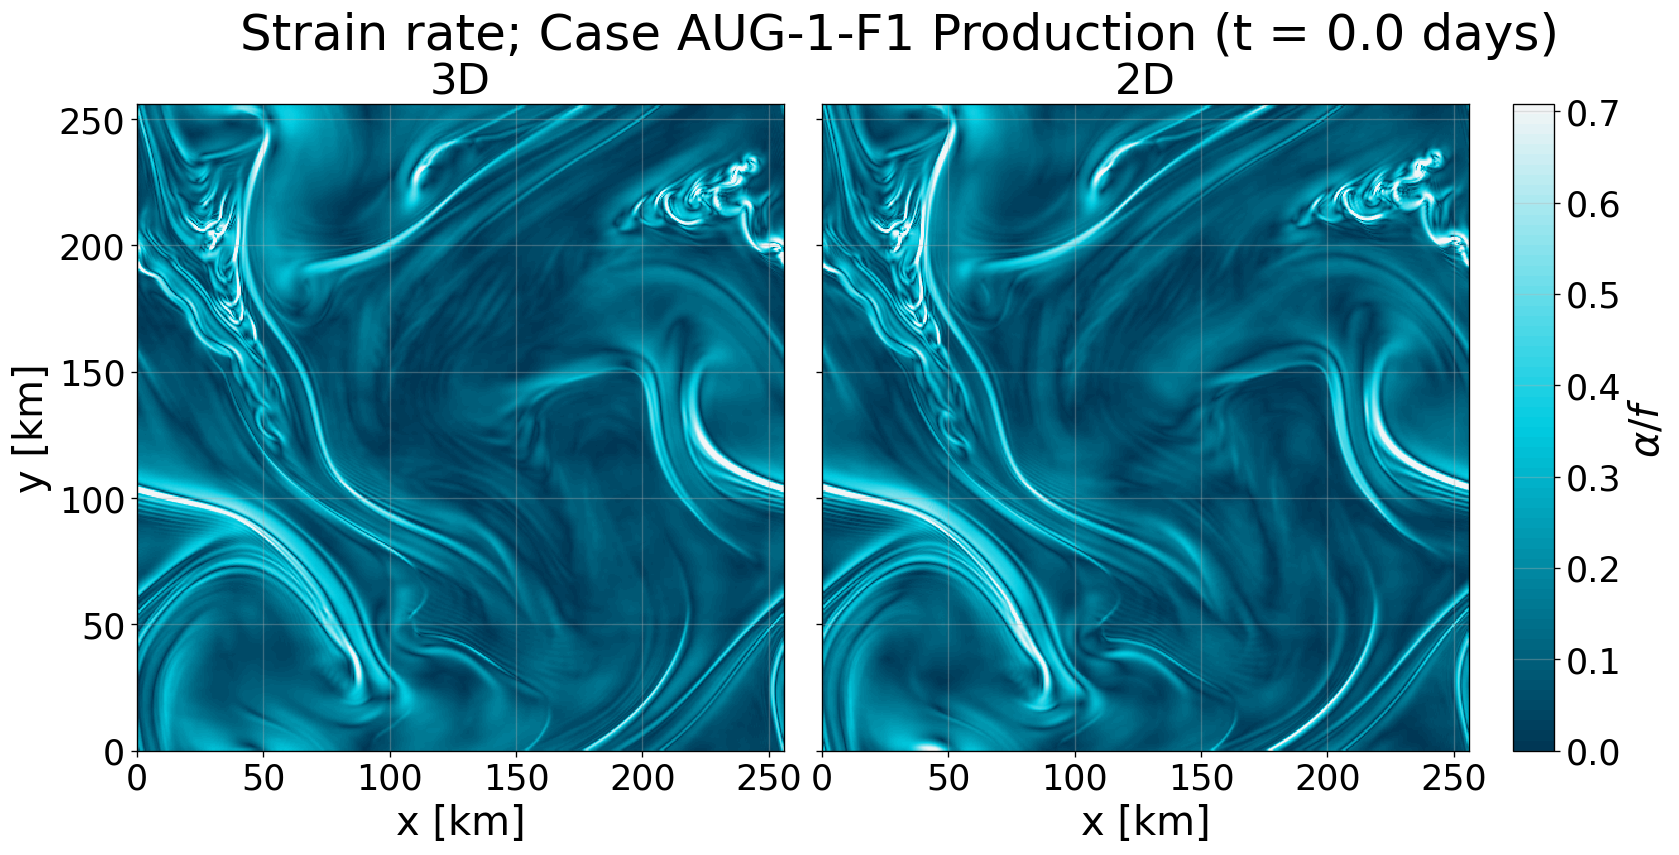

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


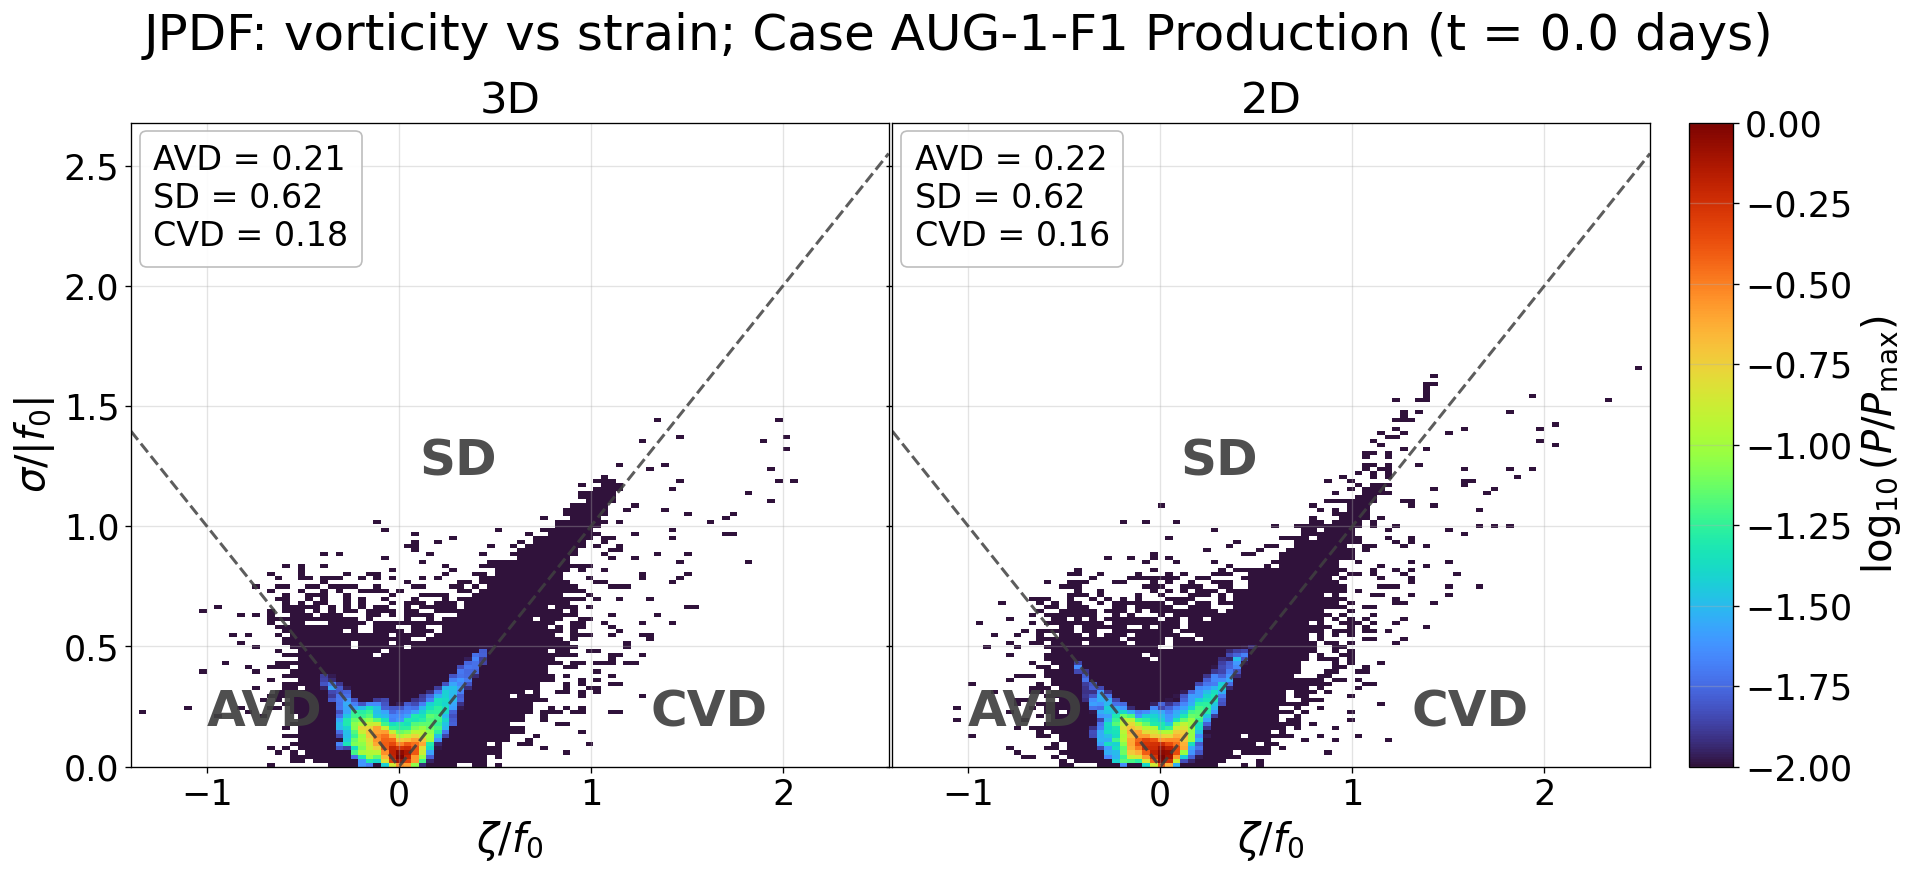

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


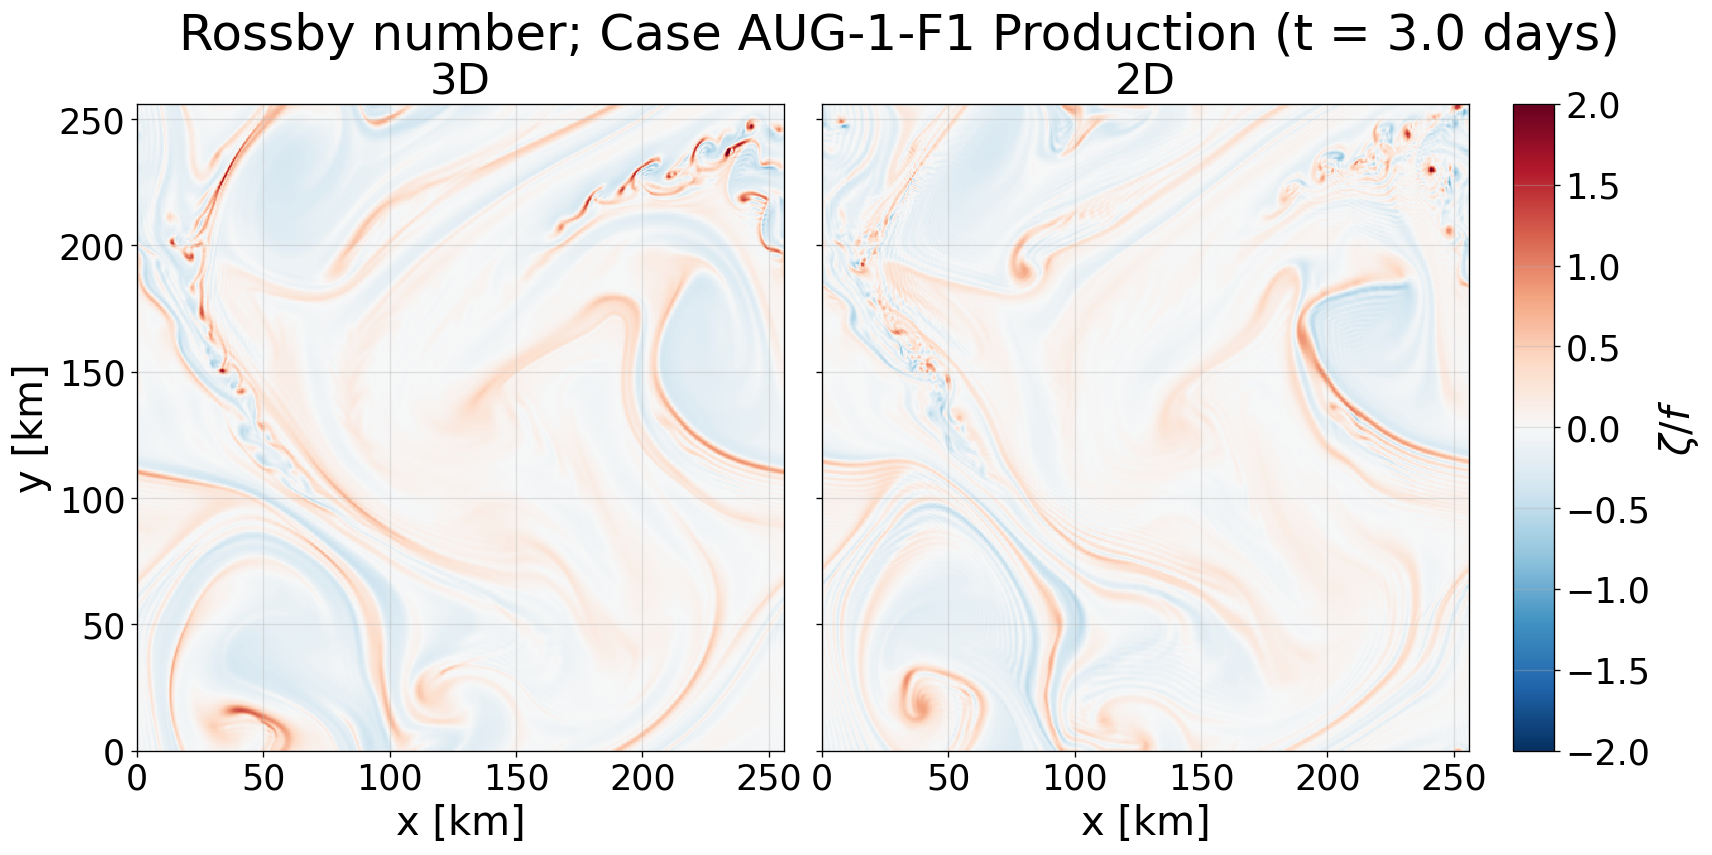

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


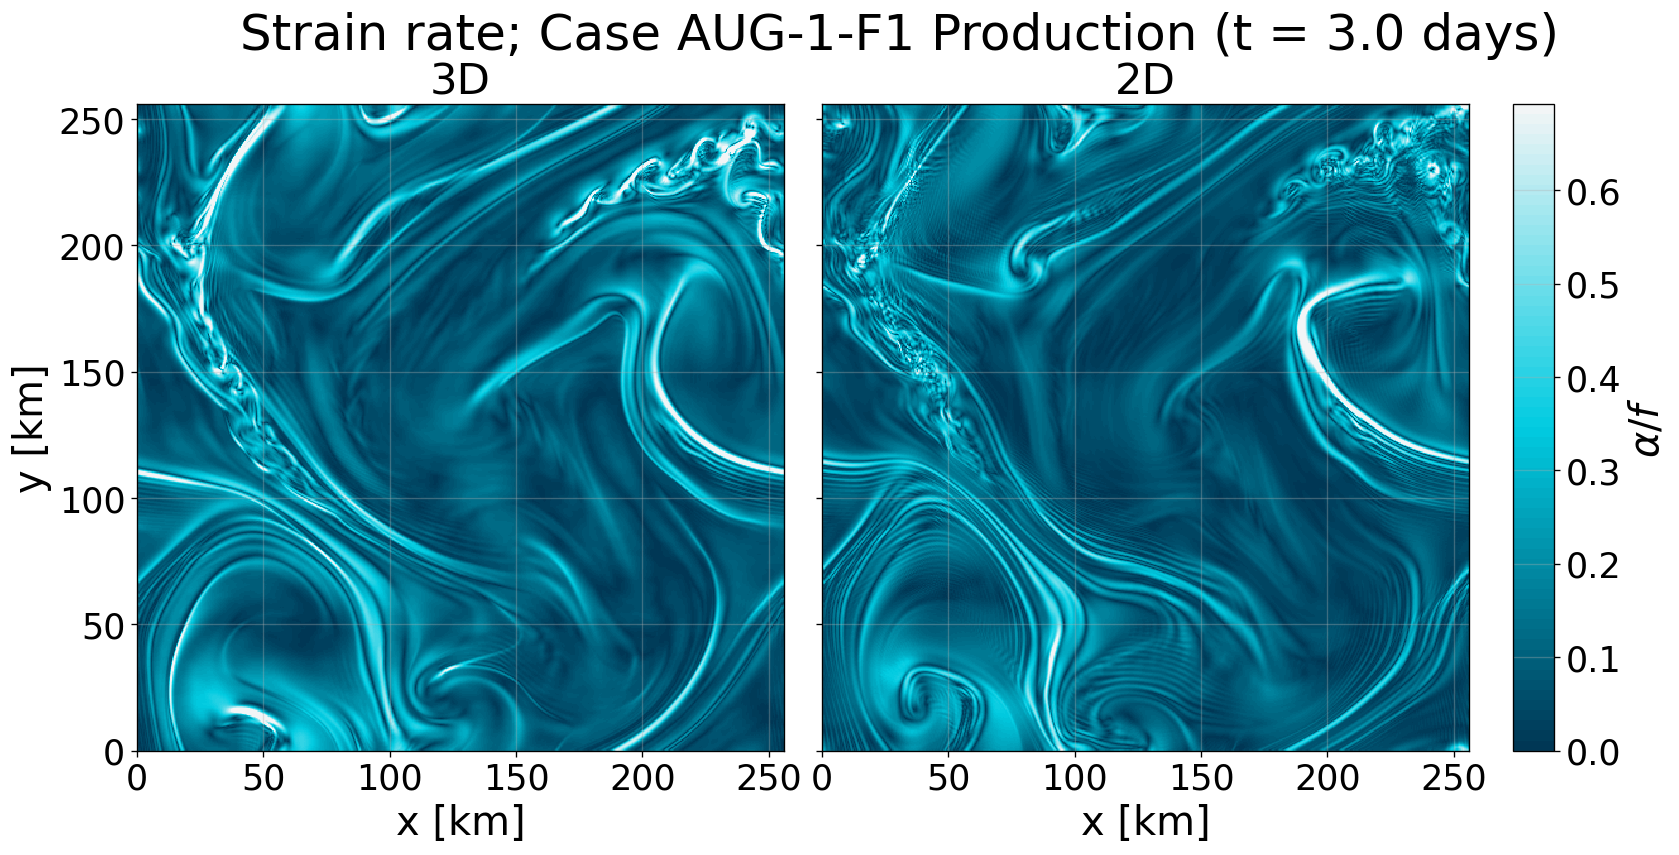

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


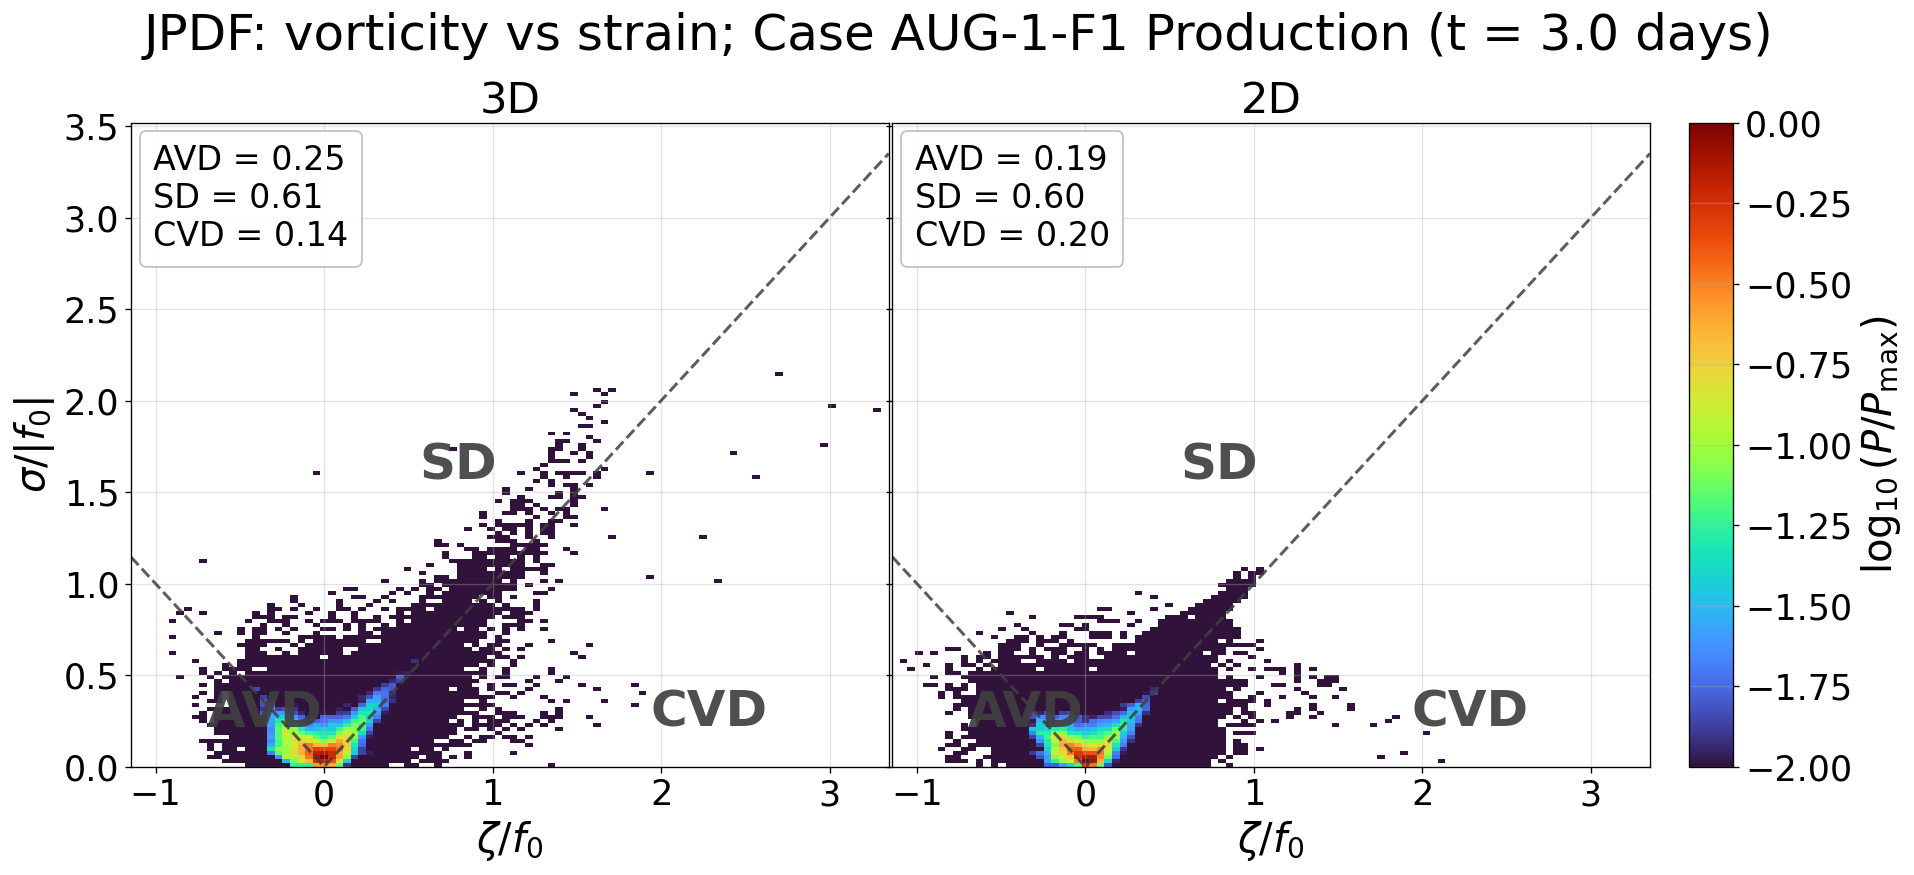

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


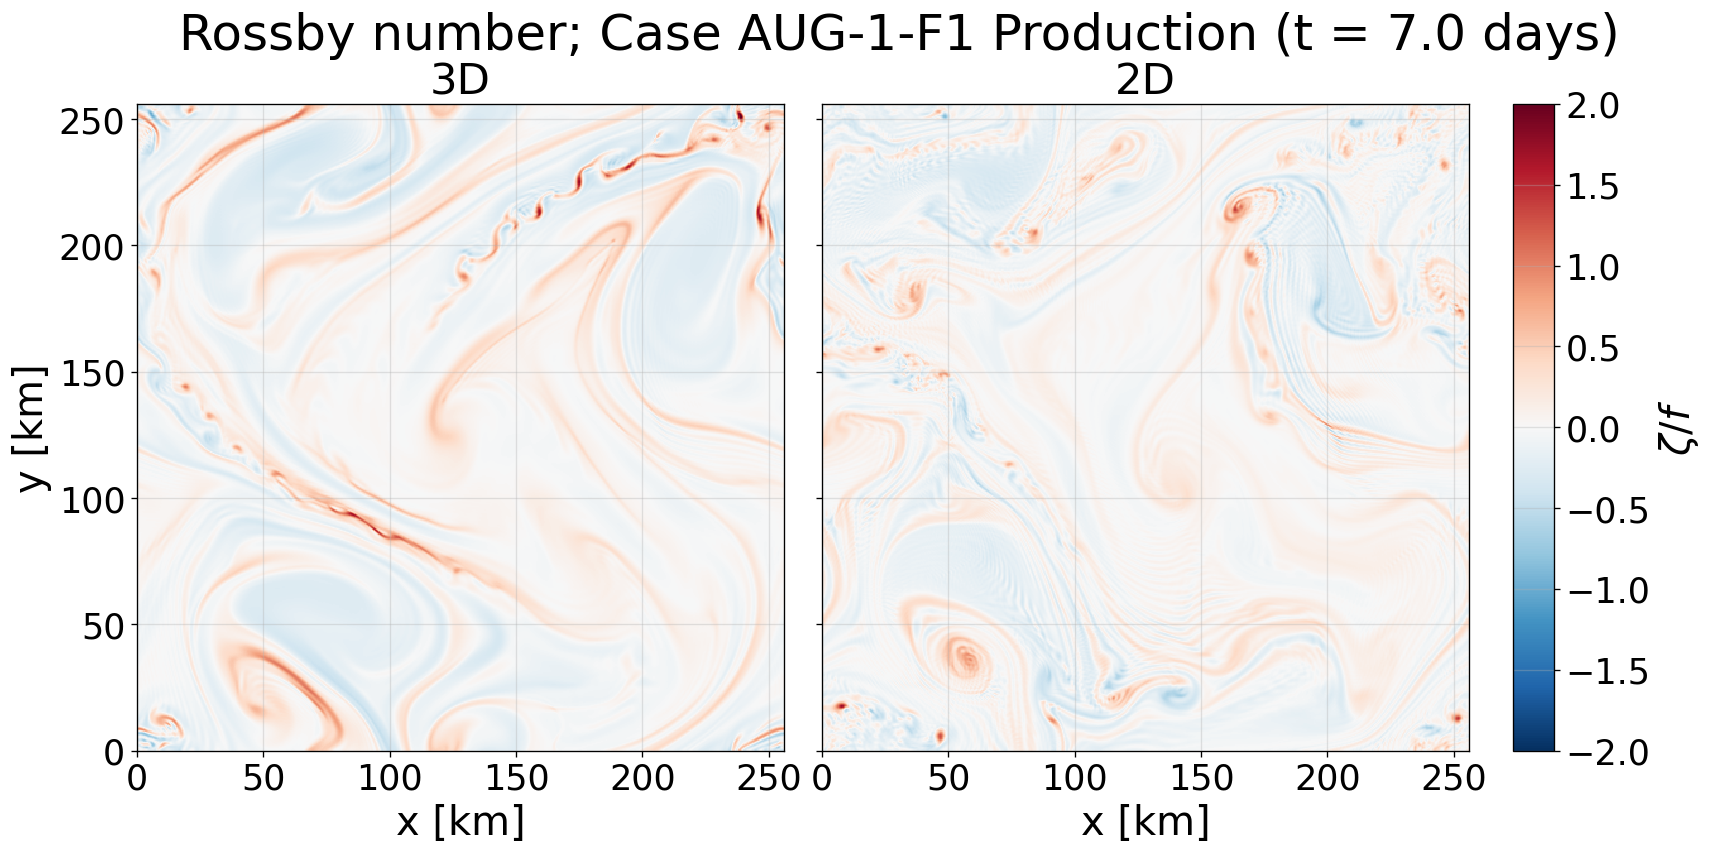

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


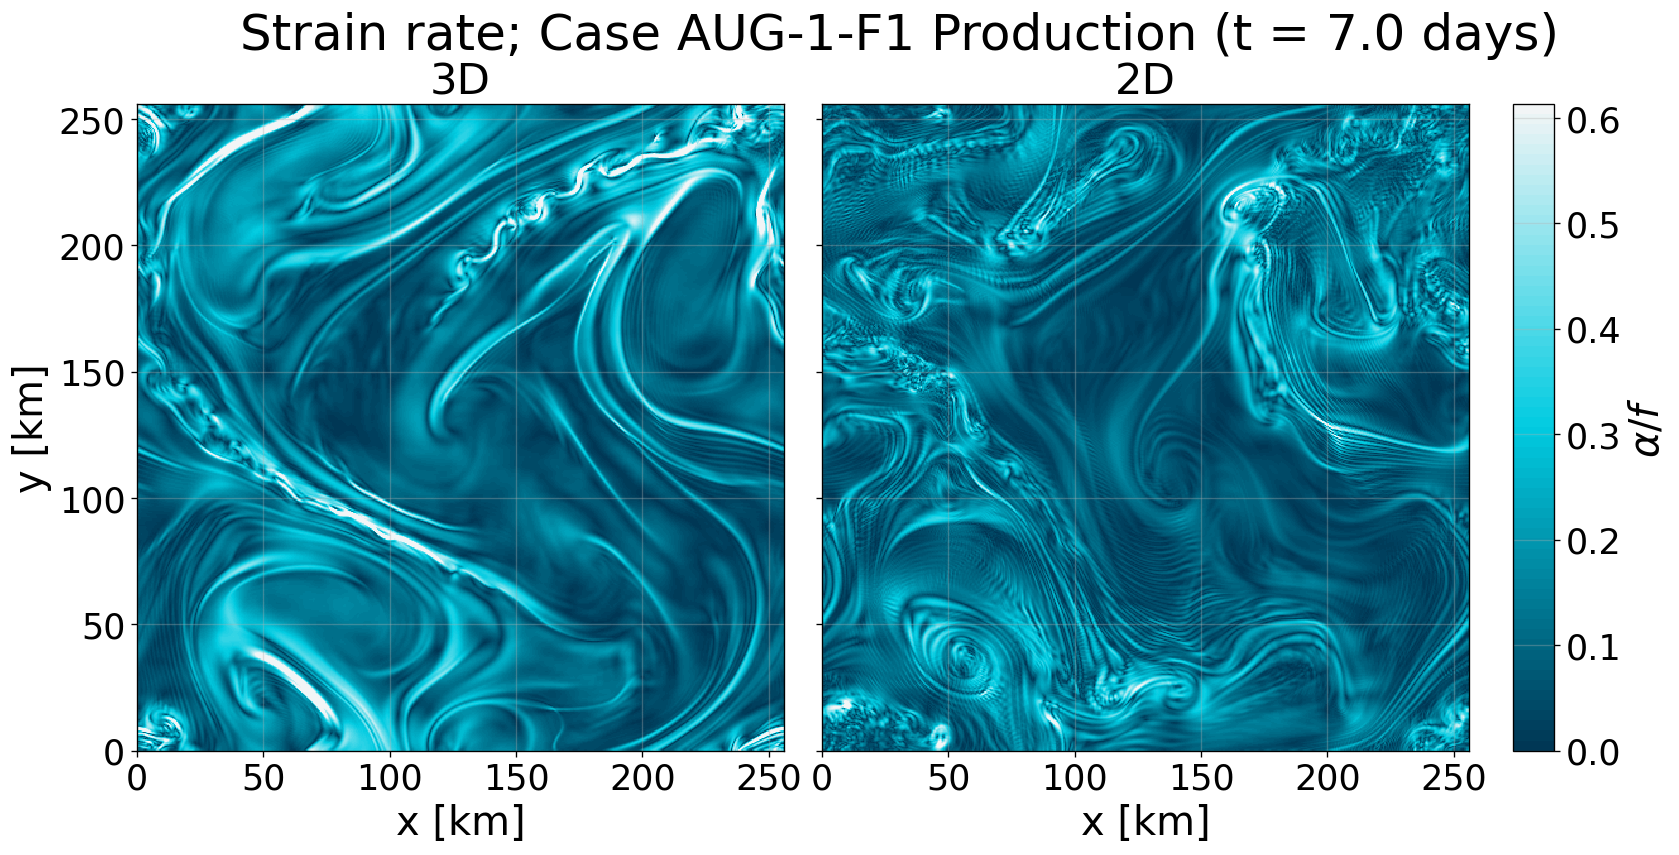

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


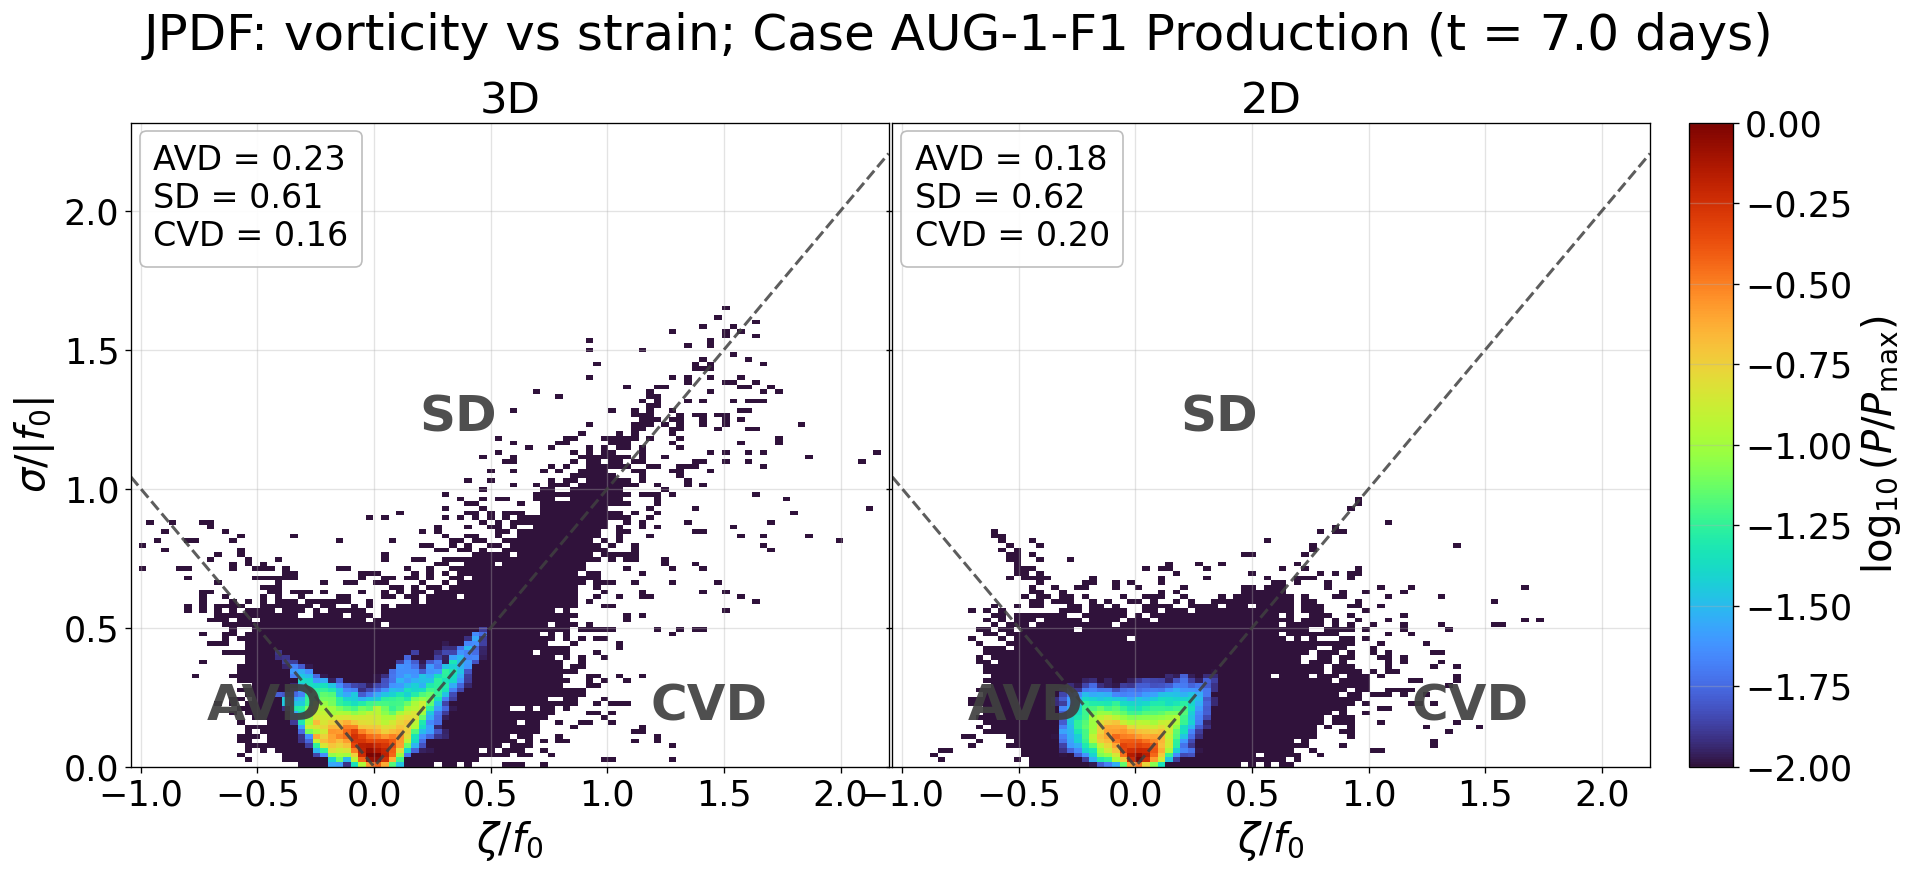

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


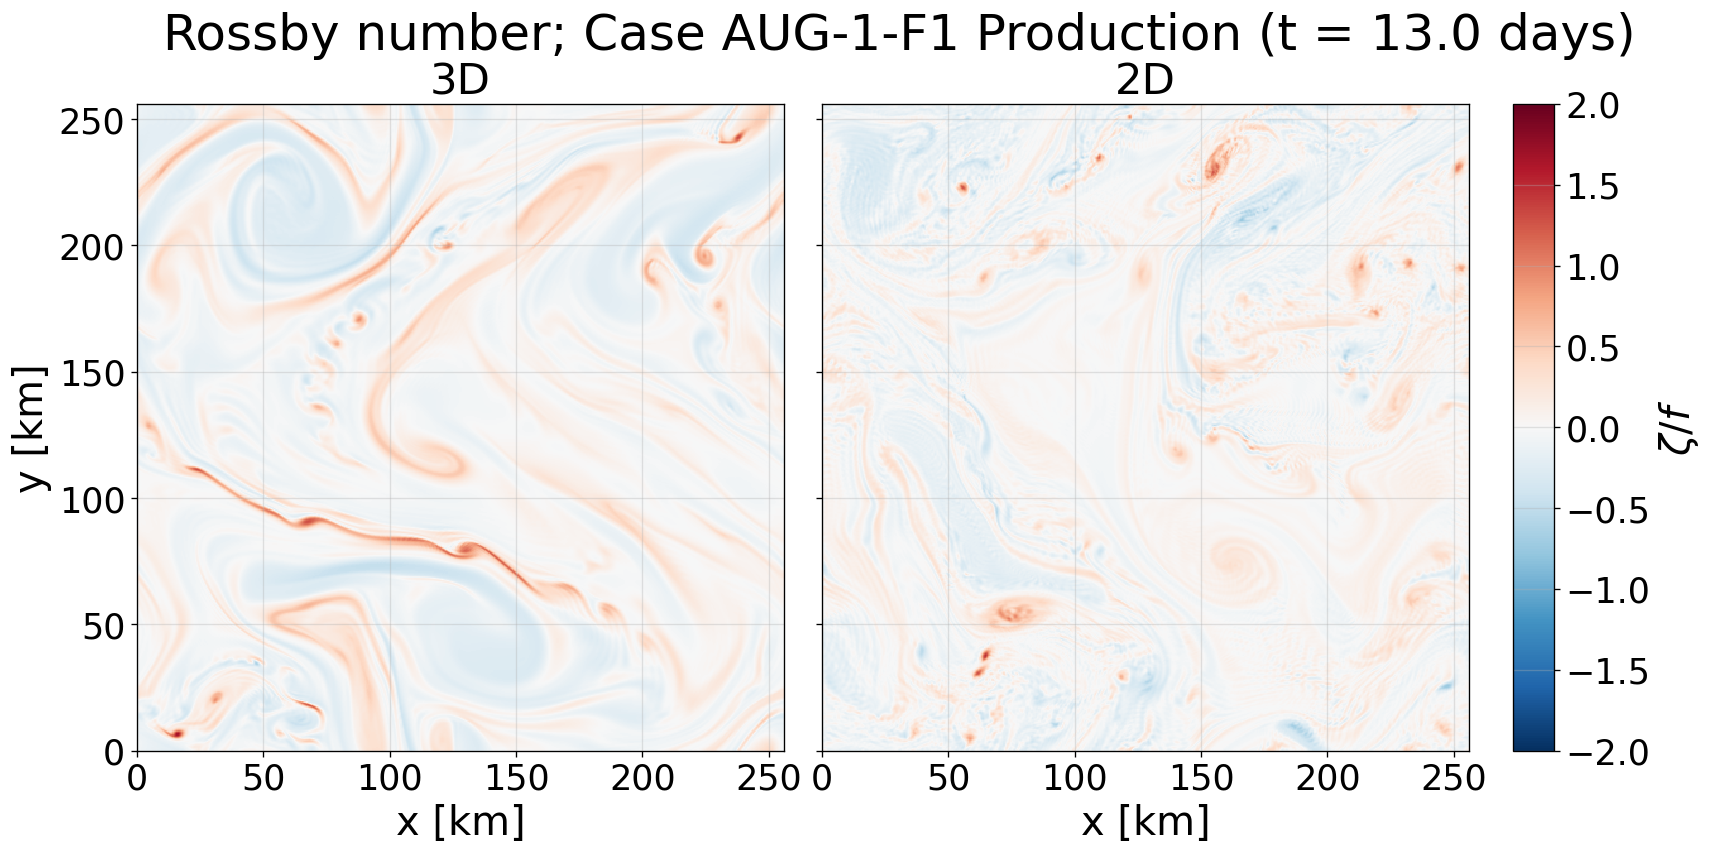

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


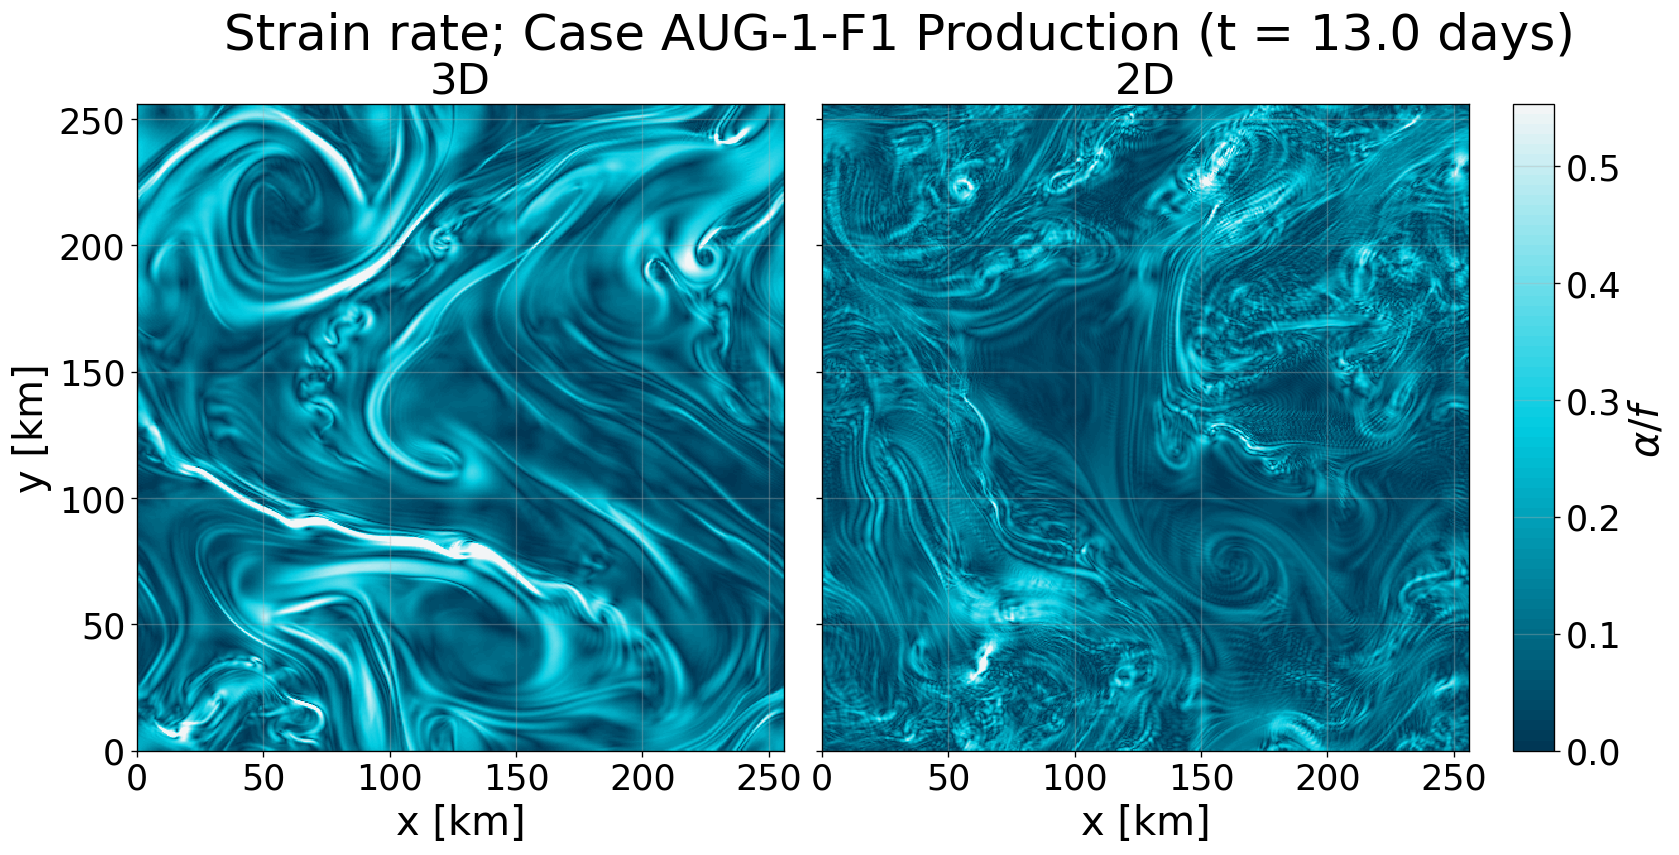

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


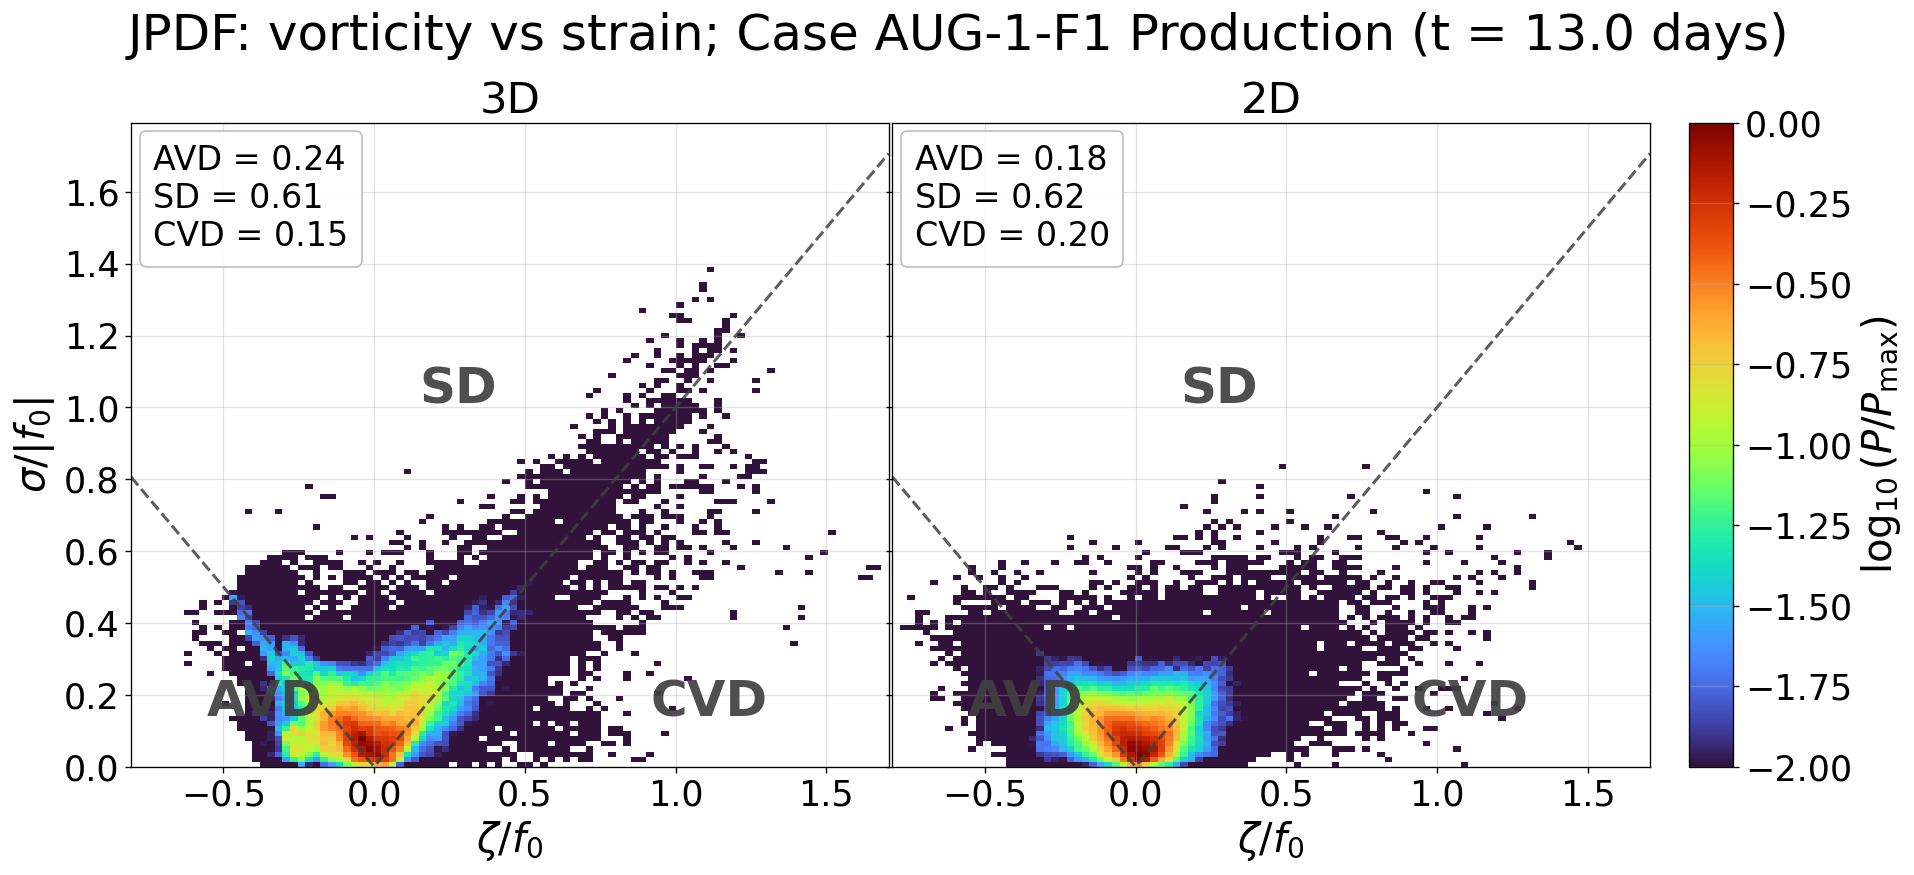

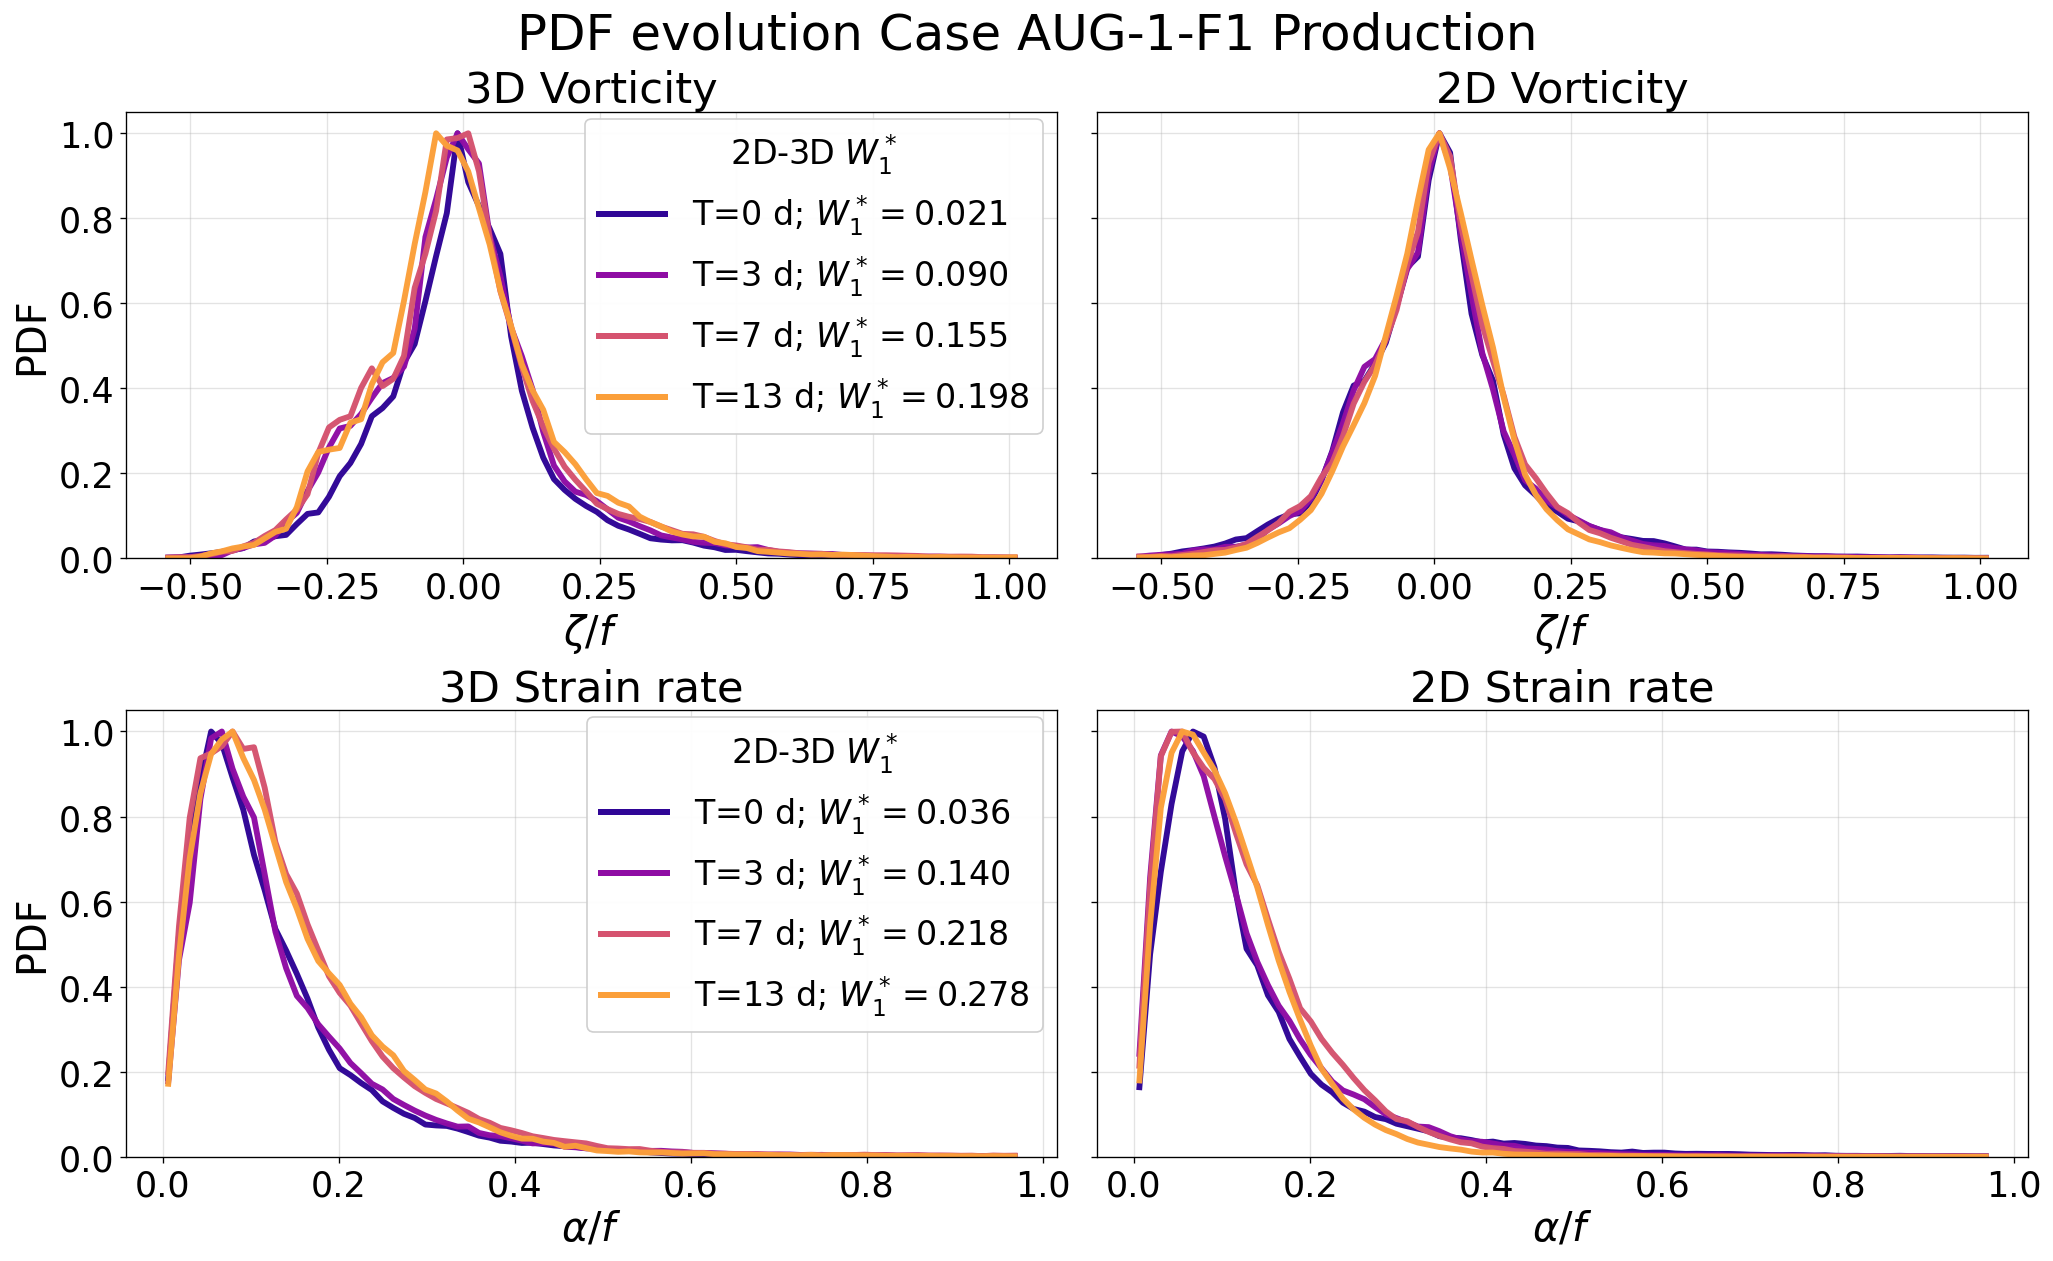

In [23]:
# ============================================================
# 7. SELECTED-SNAPSHOT COMBINED PANELS
# ============================================================

for _, row in selected_metrics_df.iterrows():
    actual_day = float(row["actual_day_3d"])
    snapshot = selected_snapshot_data[actual_day]

    day_tag = safe_filename_day(actual_day)
    obs_index = int(row["obs_index"])

    ro_3d = snapshot["ro_3d"]
    ro_2d = snapshot["ro_2d"]
    strain_3d = snapshot["strain_3d"]
    strain_2d = snapshot["strain_2d"]

    dx_plot = snapshot["dx_plot"]
    dy_plot = snapshot["dy_plot"]

    if MAKE_SELECTED_CASE_MAPS:
        plot_side_by_side_field_panel(
            ro_3d,
            ro_2d,
            dx=dx_plot,
            dy=dy_plot,
            title_left="3D",
            title_right="2D",
            suptitle=(
                f"Rossby number; {RUN_TITLE_INFO} "
                f"(t = {actual_day:.1f} days)"
            ),
            cbar_label=r"$\zeta/f$",
            cmap="rossby",
            vmin=-2.0,
            vmax=2.0,
            output_path=(
                MAP_DIR
                / f"rossby_comparison_obs{obs_index:04d}_T{day_tag}d.png"
                if SAVE_FIGURES
                else None
            ),
        )

        finite_strain_3d = strain_3d[np.isfinite(strain_3d)]
        finite_strain_2d = strain_2d[np.isfinite(strain_2d)]
        combined_strain = np.concatenate(
            [finite_strain_3d.ravel(), finite_strain_2d.ravel()]
        )
        vmax_strain = float(np.nanpercentile(np.abs(combined_strain), 99.5))

        if not np.isfinite(vmax_strain) or vmax_strain <= 0.0:
            vmax_strain = 1.0

        plot_side_by_side_field_panel(
            strain_3d,
            strain_2d,
            dx=dx_plot,
            dy=dy_plot,
            title_left="3D",
            title_right="2D",
            suptitle=(
                f"Strain rate; {RUN_TITLE_INFO} "
                f"(t = {actual_day:.1f} days)"
            ),
            cbar_label=r"$\alpha/f$",
            cmap="strain",
            vmin=0.0,
            vmax=vmax_strain,
            output_path=(
                MAP_DIR
                / f"strain_rate_comparison_obs{obs_index:04d}_T{day_tag}d.png"
                if SAVE_FIGURES
                else None
            ),
        )

    if MAKE_SELECTED_CASE_JPDFS:
        plot_combined_jpdf_panel(
            ro_3d=ro_3d,
            strain_3d=strain_3d,
            ro_2d=ro_2d,
            strain_2d=strain_2d,
            title=(
                f"JPDF: vorticity vs strain; {RUN_TITLE_INFO} "
                f"(t = {actual_day:.1f} days)"
            ),
            output_path=(
                JPDF_DIR
                / f"jpdf_vorticity_strain_obs{obs_index:04d}_T{day_tag}d.png"
                if SAVE_FIGURES
                else None
            ),
        )

if MAKE_SELECTED_CASE_PDF_EVOLUTION:
    plot_pdf_evolution_panel(
        selected_snapshot_data,
        selected_metrics_df,
        title=f"PDF evolution {RUN_TITLE_INFO}",
        output_path=(
            PDF_EVOLUTION_DIR
            / "pdf_evolution_all_selected_snapshots.png"
            if SAVE_FIGURES
            else None
        ),
    )


In [24]:
# ============================================================
# 8. OUTPUT CHECK
# ============================================================

required_selected_columns = [
    "obs_index",
    "actual_day_3d",
    "active_fraction_3d",
    "active_fraction_2d",
    "vorticity_wasserstein_iqr_normalized",
    "strain_wasserstein_iqr_normalized",
    "divergence_rms_3d",
]

missing_selected = [
    column
    for column in required_selected_columns
    if column not in selected_metrics_df.columns
]

if missing_selected:
    raise RuntimeError(
        f"Missing selected-case output columns: {missing_selected}"
    )

print("Selected-case snapshots:")
display(selected_metrics_df[required_selected_columns])

if SAVE_OUTPUTS:
    print(f"Saved activity dataset: {SELECTED_ACTIVITY_FILE}")

print(f"Saved figures inside case folder: {FIG_DIR}")
print("Done.")


Selected-case snapshots:


,obs_index,actual_day_3d,active_fraction_3d,active_fraction_2d,vorticity_wasserstein_iqr_normalized,strain_wasserstein_iqr_normalized,divergence_rms_3d
0,0,0.0,0.013107,0.014370,0.021364,0.036277,0.043828
1,24,3.0,0.017590,0.012806,0.089501,0.139787,0.048938
2,56,7.0,0.018341,0.008068,0.154779,0.217940,0.045456
3,104,13.0,0.013412,0.005348,0.198461,0.277652,0.046955


Saved activity dataset: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1_f1\metrics\submesoscale_activity_selected_snapshots.nc
Saved figures inside case folder: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1_f1\figures\2D_3D_comparison
Done.
